# TP 1 - Problema 2: Clasificación Multiclase (dígitos MNIST)

Objetivo: reconocer dígitos escritos a mano (0 al 9) a partir de imágenes
en escala de grises de 28 x 28 píxeles, con un MLP.

Dataset: MNIST en formato binario IDX (carpeta `datasets/PROBLEMA 2`).
Son 60000 imágenes de entrenamiento y 10000 de test.

MNIST no trae un conjunto de validación. Se separa uno a partir del
conjunto de entrenamiento (sección 3). Las 10000 imágenes de test se
usan una sola vez, al final.

Este notebook cubre las 8 consignas: carga, EDA, preprocesamiento,
diseño de la red, entrenamiento, evaluación, análisis de errores y
reflexión sobre las limitaciones del MLP.

### Configuración

Se importan las librerías y se fija la semilla aleatoria (42) en Python,
NumPy y PyTorch. Con la semilla fija, la división de los datos y los
resultados se repiten en cada corrida.

**Cómo ejecutarlo en Colab.** Se sube la carpeta `datasets` de `tp1` a Google
Drive, dentro de `MyDrive/AA2_TP1/`. Se elige un entorno con GPU (Entorno de
ejecución, Cambiar tipo de entorno, GPU) y se ejecutan todas las celdas. La celda
de configuración monta Drive y usa `MyDrive/AA2_TP1` como carpeta de trabajo. Las
figuras quedan en esa carpeta. Fuera de Colab, el notebook corre en CPU con las
rutas locales.

In [1]:
import os
# Solo tiene efecto en GPU: cuBLAS determinista (se define antes de usar CUDA)
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
import sys
import struct
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from scipy.stats import binomtest, chi2_contingency, fisher_exact

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo y opciones deterministas para GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

# En Colab, los datos y las figuras van a la carpeta AA2_TP1 de Drive, con la misma estructura que tp1/
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/AA2_TP1')
print(f"Dispositivo: {DEVICE}, Colab: {IN_COLAB}, carpeta de trabajo: {os.getcwd()}")

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette("muted")


Mounted at /content/drive
Dispositivo: cuda, Colab: True, carpeta de trabajo: /content/drive/MyDrive/AA2_TP1


Las librerías quedaron cargadas y la semilla fija en 42 para Python,
NumPy y PyTorch. La celda imprime el dispositivo y la carpeta de trabajo.
En esta corrida, el dispositivo es cuda (GPU de Colab) y la carpeta de
trabajo es AA2_TP1, en Drive.

## 1. Carga y verificación del dataset

Los archivos IDX no se abren como imágenes estándar. Se sigue la guía del
enunciado: se lee el encabezado en formato *big-endian* (`'>IIII'`) y
después se leen los bytes de los datos como `uint8`.

Decisiones:

- Se verifica el **número mágico** de cada archivo con un `assert`: 2051
  para imágenes y 2049 para etiquetas. Un número distinto indica un
  archivo equivocado o corrupto.
- Se verifican las dimensiones, el tipo de dato y el rango de valores
  **antes** de seguir, como pide el enunciado.

In [2]:
def load_mnist_images(filepath):
    # Encabezado: numero magico, cantidad de imagenes, filas y columnas
    with open(filepath, 'rb') as file:
        magic, num_images, rows, cols = struct.unpack('>IIII', file.read(16))
        assert magic == 2051, f"Numero magico invalido: {magic}"
        images = np.frombuffer(file.read(), dtype=np.uint8)
    return images.reshape(num_images, rows, cols)


def load_mnist_labels(filepath):
    # Encabezado: numero magico y cantidad de etiquetas
    with open(filepath, 'rb') as file:
        magic, num_labels = struct.unpack('>II', file.read(8))
        assert magic == 2049, f"Numero magico invalido: {magic}"
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels


BASE_PATH = "datasets/PROBLEMA 2"
X_train_full = load_mnist_images(os.path.join(BASE_PATH, "train-images.idx3-ubyte"))
y_train_full = load_mnist_labels(os.path.join(BASE_PATH, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(BASE_PATH, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(BASE_PATH, "t10k-labels.idx1-ubyte"))

# Verificaciones de dimensiones, tipos y rangos
assert X_train_full.shape == (60000, 28, 28) and y_train_full.shape == (60000,)
assert X_test.shape == (10000, 28, 28) and y_test.shape == (10000,)
assert X_train_full.dtype == np.uint8 and y_train_full.dtype == np.uint8
assert len(X_train_full) == len(y_train_full) and len(X_test) == len(y_test)

print(f"X_train_full: {X_train_full.shape}, dtype {X_train_full.dtype}")
print(f"y_train_full: {y_train_full.shape}, dtype {y_train_full.dtype}")
print(f"X_test:       {X_test.shape}, dtype {X_test.dtype}")
print(f"y_test:       {y_test.shape}, dtype {y_test.dtype}")
print(f"Rango de pixeles (train): [{X_train_full.min()}, {X_train_full.max()}]")
print(f"Rango de etiquetas (train): [{y_train_full.min()}, {y_train_full.max()}]")
print(f"Etiquetas distintas: {np.unique(y_train_full).tolist()}")


X_train_full: (60000, 28, 28), dtype uint8
y_train_full: (60000,), dtype uint8
X_test:       (10000, 28, 28), dtype uint8
y_test:       (10000,), dtype uint8
Rango de pixeles (train): [0, 255]
Rango de etiquetas (train): [0, 9]
Etiquetas distintas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Los cuatro archivos se cargaron con los números mágicos correctos (2051
para imágenes y 2049 para etiquetas). Todas las verificaciones pasaron:

- Train: 60000 imágenes de 28 x 28 y 60000 etiquetas.
- Test: 10000 imágenes de 28 x 28 y 10000 etiquetas.
- Las imágenes y las etiquetas son `uint8`. Los píxeles van de 0 a 255 y
  las etiquetas de 0 a 9, con los 10 dígitos presentes.

Estos valores coinciden con la tabla del enunciado, así que el análisis continúa.

## 2. Análisis exploratorio de datos (EDA)

### 2a. Muestra aleatoria de imágenes

Se muestra una grilla de 5 x 5 imágenes aleatorias con su etiqueta. El
objetivo es ver que las imágenes se cargaron bien y qué variedad de
trazos tiene el dataset. Se usa `cmap='gray'` para la escala de grises.

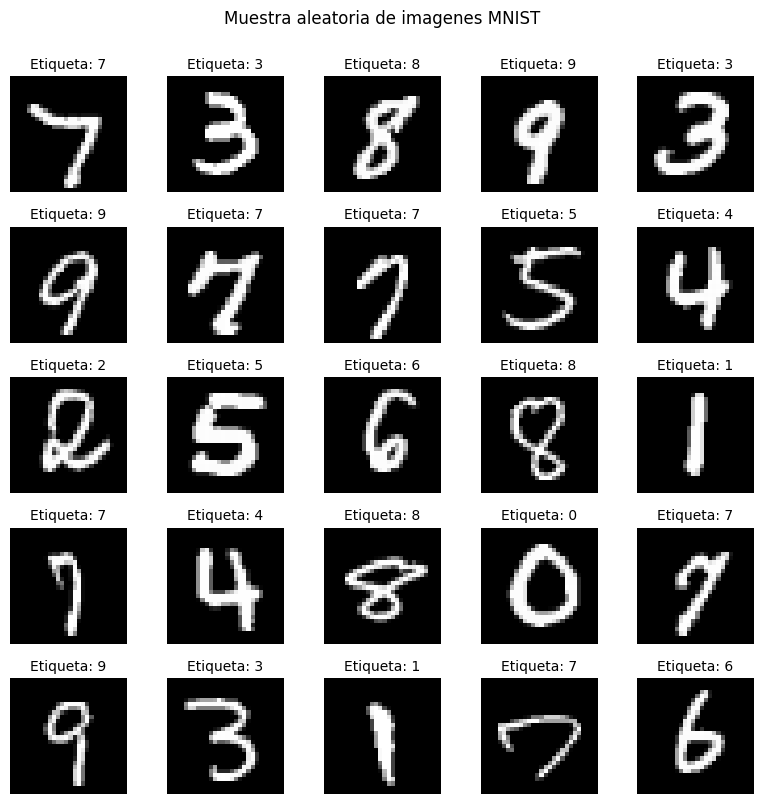

In [3]:
sample_rng = np.random.RandomState(SEED)
sample_indices = sample_rng.choice(len(X_train_full), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, index in zip(axes.flat, sample_indices):
    ax.imshow(X_train_full[index], cmap='gray')
    ax.set_title(f"Etiqueta: {y_train_full[index]}", fontsize=10)
    ax.axis('off')
fig.suptitle("Muestra aleatoria de imagenes MNIST", y=1.0)
plt.tight_layout()
plt.savefig('p2_01_muestra_imagenes.png', dpi=110, bbox_inches='tight')
plt.show()


Las imágenes se cargaron bien: los dígitos son blancos sobre fondo negro,
están centrados y las etiquetas coinciden con lo que se ve. La muestra
tiene mucha variedad de trazos. Por ejemplo, hay sietes con y sin barra
central, unos inclinados y dos con un lazo. Esta variedad anticipa
confusiones entre dígitos de forma parecida, que se analizan en la sección
de errores.

### 2b. Distribución de clases

Se cuenta cuántas imágenes hay de cada dígito en train y en test, y se
decide si el dataset está balanceado. Se compara cada clase con el 10% de un dataset de 10 clases perfectamente balanceado. También se calcula la razón entre la clase más grande y la más chica.

        train  test  train_pct  test_pct
digito                                  
0        5923   980       9.87      9.80
1        6742  1135      11.24     11.35
2        5958  1032       9.93     10.32
3        6131  1010      10.22     10.10
4        5842   982       9.74      9.82
5        5421   892       9.04      8.92
6        5918   958       9.86      9.58
7        6265  1028      10.44     10.28
8        5851   974       9.75      9.74
9        5949  1009       9.92     10.09

Clase mas grande: 1 (6742), clase mas chica: 5 (5421)
Razon mas grande / mas chica: 1.24


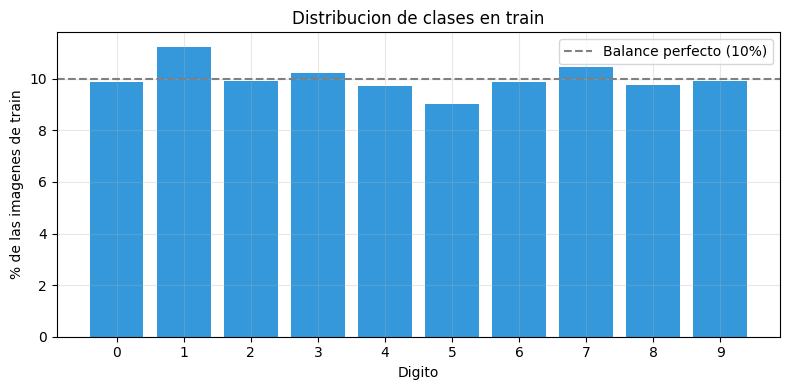

In [4]:
class_counts = pd.DataFrame({
    'train': np.bincount(y_train_full, minlength=10),
    'test': np.bincount(y_test, minlength=10),
})
class_counts['train_pct'] = class_counts['train'] / class_counts['train'].sum() * 100
class_counts['test_pct'] = class_counts['test'] / class_counts['test'].sum() * 100
class_counts.index.name = 'digito'
print(class_counts.round(2).to_string())

imbalance_ratio = class_counts['train'].max() / class_counts['train'].min()
print(f"\nClase mas grande: {class_counts['train'].idxmax()} "
      f"({class_counts['train'].max()}), clase mas chica: "
      f"{class_counts['train'].idxmin()} ({class_counts['train'].min()})")
print(f"Razon mas grande / mas chica: {imbalance_ratio:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_counts.index, class_counts['train_pct'], color='#3498db')
ax.axhline(10, color='gray', linestyle='--', label='Balance perfecto (10%)')
ax.set_xticks(range(10))
ax.set_xlabel('Digito')
ax.set_ylabel('% de las imagenes de train')
ax.set_title('Distribucion de clases en train')
ax.legend()
plt.tight_layout()
plt.savefig('p2_02_distribucion_clases.png', dpi=110, bbox_inches='tight')
plt.show()


Las clases van de 9.04% (el dígito 5, con 5421 imágenes) a 11.24% (el
dígito 1, con 6742 imágenes). La razón entre la clase más grande y la más
chica es 1.24. Test tiene proporciones parecidas, entre 8.92% y 11.35%.

**El dataset está aproximadamente balanceado.** Con una razón de 1.24, el
desbalance es chico. En el Problema 1 la razón era 19.5. Por eso no se
aplica ninguna corrección de desbalance, como `pos_weight`. Igual se
reporta la accuracy por clase en la evaluación. Así se ve si alguna
clase rinde peor, por ejemplo el 5, que es la más chica.

### 2c. Histograma de intensidad de píxeles, antes y después de normalizar

Se compara la distribución de los píxeles en la escala original (0 a 255) y en la escala normalizada. La escala normalizada va de 0 a 1 (se divide por 255). Se usan 50 bins en los dos histogramas. El eje vertical tiene escala logarítmica, porque la mayoría de los píxeles vale 0.
También se muestran la media y el desvío de cada escala.

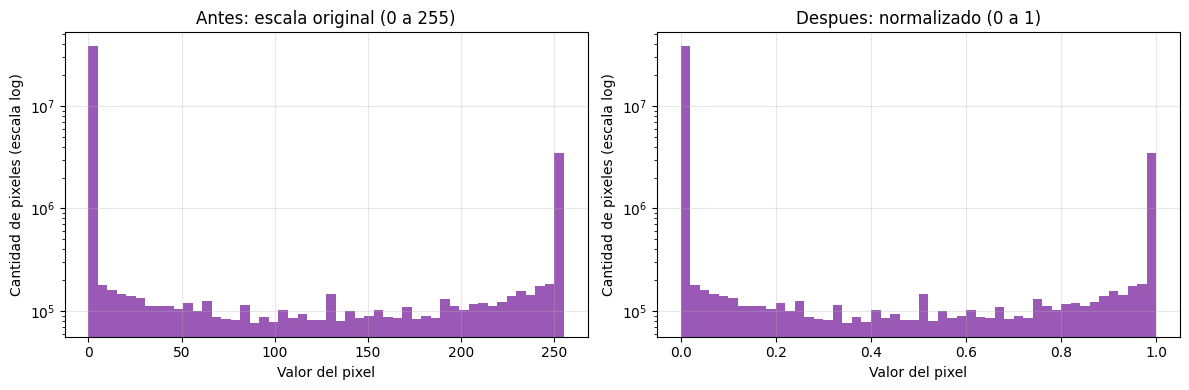

Pixeles iguales a 0:   80.9%
Pixeles iguales a 255: 0.67%
Antes:   media = 33.32, desvio = 78.57
Despues: media = 0.1307, desvio = 0.3081


In [5]:
pixels_raw = X_train_full.ravel()
pixels_normalized = pixels_raw.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pixels, value_range, title in [
        (axes[0], pixels_raw, (0, 255), 'Antes: escala original (0 a 255)'),
        (axes[1], pixels_normalized, (0, 1), 'Despues: normalizado (0 a 1)')]:
    counts, edges = np.histogram(pixels, bins=50, range=value_range)
    ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge', color='#9b59b6')
    ax.set_yscale('log')
    ax.set_xlabel('Valor del pixel')
    ax.set_ylabel('Cantidad de pixeles (escala log)')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('p2_03_histogramas_pixeles.png', dpi=110, bbox_inches='tight')
plt.show()

share_zero = (pixels_raw == 0).mean() * 100
share_max = (pixels_raw == 255).mean() * 100
print(f"Pixeles iguales a 0:   {share_zero:.1f}%")
print(f"Pixeles iguales a 255: {share_max:.2f}%")
print(f"Antes:   media = {pixels_raw.mean():.2f}, desvio = {pixels_raw.std():.2f}")
print(f"Despues: media = {pixels_normalized.mean():.4f}, "
      f"desvio = {pixels_normalized.std():.4f}")


La distribución de los píxeles es bimodal. El 80.9% de los píxeles vale
0 (fondo) y el 0.67% vale 255 (trazo pleno). Entre esos extremos, los
valores intermedios (los bordes suavizados del trazo) son mucho menos
frecuentes.

Los dos histogramas tienen la misma forma. Dividir por 255 es un cambio
lineal de escala: solo cambia el eje, de 0-255 a 0-1. La media pasa de
33.32 a 0.1307 y el desvío de 78.57 a 0.3081.

La normalización de la guía no centra los datos: la media queda en 0.13 y
el desvío en 0.31, no en 0 y 1. Un z-score con esos valores es una
alternativa. Esta alternativa no se usa.

## 3. Preprocesamiento

### 3a. División en train, validación y test

MNIST trae solo train (60000) y test (10000). El enunciado pide tres
conjuntos separados. Decisiones:

- **Validación**: 6000 imágenes (10%) tomadas de las 60000 de train. Da
  unas 600 imágenes por clase, suficiente para medir la pérdida y la
  accuracy sin quitarle demasiados datos al entrenamiento.
- **Estratificada** por dígito, para que train y validación conserven la
  misma proporción de cada clase.
- **Test**: las 10000 imágenes oficiales. No se usan para tomar
  decisiones. Se evalúan una sola vez, al final.

In [6]:
train_indices, val_indices = train_test_split(
    np.arange(len(X_train_full)), test_size=6000,
    stratify=y_train_full, random_state=SEED)

X_train, y_train = X_train_full[train_indices], y_train_full[train_indices]
X_val, y_val = X_train_full[val_indices], y_train_full[val_indices]

print(f"Train: {len(X_train)} imagenes | Val: {len(X_val)} | Test: {len(X_test)}")
split_shares = pd.DataFrame({
    'train_%': np.bincount(y_train, minlength=10) / len(y_train) * 100,
    'val_%': np.bincount(y_val, minlength=10) / len(y_val) * 100,
    'test_%': np.bincount(y_test, minlength=10) / len(y_test) * 100,
})
split_shares.index.name = 'digito'
print(split_shares.round(2).to_string())
print(f"\nDiferencia maxima train vs val: "
      f"{(split_shares['train_%'] - split_shares['val_%']).abs().max():.3f} puntos")


Train: 54000 imagenes | Val: 6000 | Test: 10000
        train_%  val_%  test_%
digito                        
0          9.87   9.87    9.80
1         11.24  11.23   11.35
2          9.93   9.93   10.32
3         10.22  10.22   10.10
4          9.74   9.73    9.82
5          9.04   9.03    8.92
6          9.86   9.87    9.58
7         10.44  10.45   10.28
8          9.75   9.75    9.74
9          9.91   9.92   10.09

Diferencia maxima train vs val: 0.009 puntos


Quedaron 54000 imágenes en train, 6000 en validación y 10000 en test. En
train y validación, el porcentaje de cada dígito difiere en 0.009 puntos
como máximo, así que la estratificación funcionó. Las proporciones de test
difieren de las de train hasta 0.39 puntos (el dígito 2). El test
oficial se dejó sin cambios.

### 3b. Aplanamiento y normalización de los píxeles

Un MLP necesita un vector por ejemplo, así que cada imagen (28 x 28) se
aplana a un vector de 784 valores. Los píxeles se convierten a `float32` y
se dividen por 255 para llevarlos al rango [0, 1], como indica la guía.

Dividir por 255 usa una constante fija. No se calcula ningún parámetro con
los datos, así que no hay riesgo de fuga de información entre train,
validación y test. En el Problema 1, en cambio, el escalado z-score se
ajustaba solo con train.

In [7]:
def flatten_and_normalize(images):
    # (N, 28, 28) uint8 -> (N, 784) float32 en el rango [0, 1]
    return images.reshape(len(images), -1).astype(np.float32) / 255.0


X_train_flat = flatten_and_normalize(X_train)
X_val_flat = flatten_and_normalize(X_val)
X_test_flat = flatten_and_normalize(X_test)

print(f"X_train_flat: {X_train_flat.shape}, dtype {X_train_flat.dtype}")
print(f"X_val_flat:   {X_val_flat.shape}")
print(f"X_test_flat:  {X_test_flat.shape}")
print(f"Rango: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
assert X_train_flat.shape[1] == 28 * 28
assert 0.0 <= X_train_flat.min() and X_train_flat.max() <= 1.0


X_train_flat: (54000, 784), dtype float32
X_val_flat:   (6000, 784)
X_test_flat:  (10000, 784)
Rango: [0.0, 1.0]


Los tres conjuntos tienen 784 columnas y tipo `float32`: train 54000 x
784, validación 6000 x 784 y test 10000 x 784. El rango de train es
[0.0, 1.0].

La normalización sigue el apunte de la Unidad 5. Los píxeles en [0, 255]
producen gradientes mucho mayores que los valores en [0, 1]. Eso dificulta
el entrenamiento.

### 3c. Codificación de las etiquetas: enteros en lugar de one-hot

El enunciado pide justificar la elección entre one-hot y enteros.
Se eligieron **etiquetas enteras (0 a 9)** con `nn.CrossEntropyLoss`.

- `nn.CrossEntropyLoss` recibe las salidas crudas de la red (logits) y el
  índice de la clase verdadera. Aplica softmax internamente y toma el
  logaritmo negativo de la probabilidad de la clase verdadera.
- Con una etiqueta one-hot, la cross-entropy categórica es
  `-sum(y_k * log p_k)`. Como solo un `y_k` vale 1, la suma se reduce a
  `-log p_verdadera`. Es el mismo término que selecciona el índice entero.
  La pérdida y los gradientes son idénticos (apunte de la Unidad 2).
- El apunte justifica one-hot para no imponer un orden entre clases. Esa
  razón vale cuando el entero es una entrada o un objetivo numérico. Aquí
  el entero solo indica qué salida de la red entra en la pérdida. La red
  no hace cuentas con ese número, y no aprende que "5 es mayor que 3".
- El one-hot sigue siendo necesario en otros casos: `categorical_crossentropy`
  de Keras, etiquetas suaves (*label smoothing*) o clasificación multilabel.

Se comprueba la equivalencia de forma numérica: se calcula la pérdida con
enteros y con one-hot sobre los mismos logits aleatorios.

In [8]:
check_generator = torch.Generator().manual_seed(SEED)
random_logits = torch.randn(1000, 10, generator=check_generator)
random_labels = torch.randint(0, 10, (1000,), generator=check_generator)

# Perdida con etiquetas enteras (la que se usa)
loss_integer = nn.CrossEntropyLoss()(random_logits, random_labels)

# Perdida con etiquetas one-hot, calculada a mano: -sum(y_k * log p_k)
one_hot_labels = torch.nn.functional.one_hot(random_labels, num_classes=10).float()
log_probabilities = torch.log_softmax(random_logits, dim=1)
loss_one_hot = -(one_hot_labels * log_probabilities).sum(dim=1).mean()

print(f"Perdida con enteros:  {loss_integer.item():.8f}")
print(f"Perdida con one-hot:  {loss_one_hot.item():.8f}")
print(f"Diferencia absoluta:  {abs(loss_integer.item() - loss_one_hot.item()):.2e}")
assert torch.isclose(loss_integer, loss_one_hot, atol=1e-6)
print(f"Memoria de las etiquetas de train: enteros (int64) "
      f"{y_train.astype(np.int64).nbytes} bytes, one-hot (float32) "
      f"{len(y_train) * 10 * 4} bytes")


Perdida con enteros:  2.71831250
Perdida con one-hot:  2.71831250
Diferencia absoluta:  0.00e+00
Memoria de las etiquetas de train: enteros (int64) 432000 bytes, one-hot (float32) 2160000 bytes


La pérdida con etiquetas enteras y con one-hot da el mismo valor sobre los
mismos logits (2.71831250 en los dos casos, diferencia 0). La comprobación
confirma que, para `CrossEntropyLoss`, las dos codificaciones son
equivalentes. El propio apunte de la Unidad 2 (sección 2.2.4, Listing 2.1) usa
índices enteros con `CrossEntropyLoss`.

Las etiquetas enteras ocupan 432000 bytes (como `int64`) y las one-hot
2160000 bytes (como `float32`), unas 5 veces más. En valores absolutos es
poco, y no decide la elección. Decide la simplicidad: con enteros, el
accuracy se calcula al comparar el `argmax` con la etiqueta, sin pasos
intermedios.

**Decisión: etiquetas enteras con `nn.CrossEntropyLoss`.**

## 4. Diseño e implementación de la red neuronal

Diseño del MLP para clasificar los 10 dígitos. El apunte de la materia no
fija una arquitectura para MNIST. Las decisiones siguen los ejemplos y las
reglas prácticas de los apuntes, y se indican una por una.

- **Capas ocultas y neuronas** (4a): 2 capas ocultas de 256 y 128
  neuronas (784 -> 256 -> 128 -> 10). El ejemplo del apunte de la Unidad 4 (sección 4.3.4, Listing 3.1) usa esas mismas 256 y 128 unidades para 10 clases. Es un
  tamaño moderado y no se optimizó: no se comparó con otros tamaños
  antes de entrenar. La sección 8 mide si importa.
- **Activación oculta** (4a): ReLU, el valor por defecto para capas ocultas
  según el apunte de la Unidad 1, con inicialización Kaiming (Unidad 3).
  En el Problema 1 no se encontró una diferencia medible entre ReLU y Leaky
  ReLU, así que se usa el valor por defecto.
- **Capa de salida** (4a): 10 neuronas sin activación, es decir, 10 logits.
  Softmax es la activación de salida para clases excluyentes (apunte de la
  Unidad 2): convierte los 10 logits en probabilidades positivas que suman 1.
  `nn.CrossEntropyLoss` la aplica internamente, y el apunte indica que
  espera logits crudos. Para predecir, se toma el `argmax` de los logits.
  Da la misma clase que el `argmax` de las probabilidades, porque softmax
  conserva el orden.
- **Función de costo** (4b): `nn.CrossEntropyLoss` con etiquetas enteras
  (sección 3c). Es la cross-entropy categórica, la función de costo
  apropiada para clasificación multiclase.
- **Optimizador** (4c): Adam con tasa de aprendizaje `1e-3`, el valor por
  defecto del apunte de la Unidad 3. Se usan batches de 128 imágenes. El
  tamaño del batch es una convención, y no se midió.
- **Regularización** (4d): Dropout de 0.3 después de cada capa oculta, y
  Early Stopping sobre la pérdida de validación (paciencia 10). El apunte de la Unidad 4 indica que con datasets grandes bastan tasas de 0.3 o menos. También indica que no se aplica Dropout a la capa de salida. Train tiene 54000
  imágenes. Su ejemplo usa 0.5 y 0.3. Se eligió 0.3 en las dos capas por el
  tamaño del dataset. Es un valor de partida, y la sección 8 mide si
  Dropout ayuda.

In [9]:
class DigitMLP(nn.Module):
    """MLP para MNIST: 784 -> hidden_sizes -> 10 logits."""

    def __init__(self, n_inputs=784, hidden_sizes=(256, 128), n_classes=10,
                 dropout=0.3):
        super().__init__()
        layers = []
        in_features = n_inputs
        for out_features in hidden_sizes:
            layers += [nn.Linear(in_features, out_features),
                       nn.ReLU(),
                       nn.Dropout(dropout)]
            in_features = out_features
        # Capa de salida: sin activacion (logits) y sin Dropout
        layers.append(nn.Linear(in_features, n_classes))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        # Kaiming para las capas con ReLU, y 'linear' para la capa de salida
        linear_layers = [m for m in self.net if isinstance(m, nn.Linear)]
        for layer in linear_layers[:-1]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)
        nn.init.kaiming_normal_(linear_layers[-1].weight, nonlinearity='linear')
        nn.init.zeros_(linear_layers[-1].bias)

    def forward(self, x):
        return self.net(x)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
model = DigitMLP().to(DEVICE)

params_per_layer = [(name, p.numel()) for name, p in model.named_parameters()]
n_params = sum(count for _, count in params_per_layer)
print(f"Device: {DEVICE}")
print(f"Parametros entrenables: {n_params}")
print(f"Parametros por imagen de train: {n_params / len(X_train_flat):.2f}")
print(model)

# Verificacion de formas: un batch de 4 imagenes produce 4 x 10 logits.
# En modo eval y sin gradiente, el Dropout no consume numeros aleatorios.
model.eval()
with torch.no_grad():
    example_logits = model(torch.from_numpy(X_train_flat[:4]).to(DEVICE))
print(f"Forma de la salida para 4 imagenes: {tuple(example_logits.shape)}")


Device: cuda
Parametros entrenables: 235146
Parametros por imagen de train: 4.35
DigitMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
Forma de la salida para 4 imagenes: (4, 10)


La red tiene 235146 parámetros entrenables. La primera capa tiene 200960
(784 x 256 más 256 sesgos), la segunda 32896 y la de salida 1290. La
primera capa concentra el 85% de los parámetros. La relación es de 4.35
parámetros por imagen en train.

La forma de la salida, (4, 10), confirma que la red produce 10 logits por
imagen. Las capas de Dropout quedan entre las capas ocultas y no aparecen
en la capa de salida.

### 4.1 DataLoaders

Los arrays de la sección 3 se convierten en tensores de PyTorch, y se crea un
`DataLoader` por conjunto. Las etiquetas pasan a `int64`, el tipo que
`CrossEntropyLoss` espera para los índices de clase. Train se mezcla en
cada época (`shuffle=True`). Validación y test no, porque su orden no
cambia el resultado.

**Cada `DataLoader` tiene su propio generador** de números aleatorios, con la
semilla 42. Sin un generador propio, cada recorrido de un `DataLoader`
consume números del generador global de PyTorch, que también usa el Dropout.
Así, una misma semilla daba resultados distintos según el número de recorridos de un
loader antes de entrenar. También se agrega un loader de train sin
mezclar, solo para medir las métricas de train. Para mostrar un batch de
ejemplo, se leen las primeras 128 filas del dataset, sin recorrer el loader.

In [10]:
BATCH_SIZE = 128


def make_loader(features, labels, shuffle, seed=SEED):
    dataset = TensorDataset(torch.from_numpy(features),
                            torch.from_numpy(labels.astype(np.int64)))
    # Generador propio: recorrer el loader no consume el azar global de PyTorch
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      generator=generator)


train_loader = make_loader(X_train_flat, y_train, shuffle=True)
train_eval_loader = make_loader(X_train_flat, y_train, shuffle=False)
val_loader = make_loader(X_val_flat, y_val, shuffle=False)
test_loader = make_loader(X_test_flat, y_test, shuffle=False)

print(f"Batches por epoca -> train: {len(train_loader)}, "
      f"val: {len(val_loader)}, test: {len(test_loader)}")
x_batch, y_batch = train_loader.dataset[:BATCH_SIZE]
print(f"Batch de train: x {tuple(x_batch.shape)} {x_batch.dtype}, "
      f"y {tuple(y_batch.shape)} {y_batch.dtype}")


Batches por epoca -> train: 422, val: 47, test: 79
Batch de train: x (128, 784) torch.float32, y (128,) torch.int64


Los tres `DataLoader` están listos: 422 batches por época en train, 47 en
validación y 79 en test. Un batch de train tiene la forma (128, 784) en
`float32` para las imágenes, y (128,) en `int64` para las etiquetas. Son
los tipos que espera `CrossEntropyLoss`.

## 5. Entrenamiento y curvas de aprendizaje

El modelo se entrena con las decisiones de la sección 4. Decisiones del ciclo de
entrenamiento:

- **Máximo de épocas**: 50, como el ejemplo del apunte de la Unidad 4. Es
  un techo, y el Early Stopping corta antes si hace falta.
- **Early Stopping**: monitorea `val_loss`. Si no mejora al menos `1e-4`
  durante 10 épocas seguidas, el entrenamiento se detiene y el modelo
  vuelve a los pesos de la mejor época.
- **Métricas de seguimiento**: pérdida y accuracy. Las clases están
  balanceadas (sección 2b), así que la accuracy es una métrica válida
  para seguir el entrenamiento.
- **Métricas de train**: se calculan en modo `eval()` (sin Dropout) al
  final de cada época. Así la comparación con validación es justa.

In [11]:
def evaluate(model, loader, criterion):
    """Devuelve (perdida promedio, accuracy) sobre un DataLoader."""
    model.eval()
    total_loss, total_correct = 0.0, 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(x_batch)
            total_loss += criterion(logits, y_batch).item() * len(x_batch)
            total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
    n_examples = len(loader.dataset)
    return total_loss / n_examples, total_correct / n_examples


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

MAX_EPOCHS = 50
PATIENCE = 10
MIN_DELTA = 1e-4

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss, best_state, best_epoch = float('inf'), None, 0
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    # Un paso de entrenamiento sobre todos los batches de train
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()

    # Metricas de fin de epoca, en modo eval (sin Dropout)
    train_loss, train_acc = evaluate(model, train_eval_loader, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early Stopping sobre val_loss
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch = val_loss, epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoca {epoch:3d} | train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} | train_acc={train_acc:.4f} "
              f"val_acc={val_acc:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly Stopping en la epoca {epoch}.")
        break

# Volver a los pesos de la mejor epoca
model.load_state_dict(best_state)
print(f"Tiempo de entrenamiento: {time.time() - start_time:.0f} s")
print(f"Mejor epoca: {best_epoch} (val_loss={best_val_loss:.4f}, "
      f"val_acc={history['val_acc'][best_epoch - 1]:.4f})")


Epoca   1 | train_loss=0.1471 val_loss=0.1677 | train_acc=0.9558 val_acc=0.9510
Epoca   5 | train_loss=0.0420 val_loss=0.0843 | train_acc=0.9871 val_acc=0.9752
Epoca  10 | train_loss=0.0178 val_loss=0.0823 | train_acc=0.9944 val_acc=0.9775
Epoca  15 | train_loss=0.0083 val_loss=0.0844 | train_acc=0.9977 val_acc=0.9792
Epoca  20 | train_loss=0.0072 val_loss=0.0916 | train_acc=0.9983 val_acc=0.9797

Early Stopping en la epoca 21.
Tiempo de entrenamiento: 57 s
Mejor epoca: 11 (val_loss=0.0776, val_acc=0.9797)


El entrenamiento duró 57 segundos. Se detuvo por Early Stopping en la
época 21. El modelo conserva los pesos de la época 11, con `val_loss = 0.0776` y
val_acc = 0.9797. La corrida anterior en CPU daba la misma pérdida y
`val_acc = 0.9808`, en la época 12.

La pérdida de train baja de 0.1471 a 0.0069. La pérdida de validación baja de
0.1677 a cerca de 0.08 en las primeras 5 épocas. Después oscila entre 0.078 y
0.090 hasta la época 19, con su mínimo en la época 11. Sube a 0.0916 en la
época 20 y a 0.1006 en la época 21. La accuracy de validación sube de 0.9510 a
cerca de 0.98.

### 5.1 Curvas de aprendizaje

Se grafican la pérdida y la accuracy por época, en train y en validación.
Una brecha creciente entre las curvas indica sobreajuste. Dos curvas
altas y juntas indican subajuste. La línea vertical marca la época cuyos pesos conserva el modelo. Si hay sobreajuste, es ese punto: desde ahí la pérdida de validación deja de bajar.

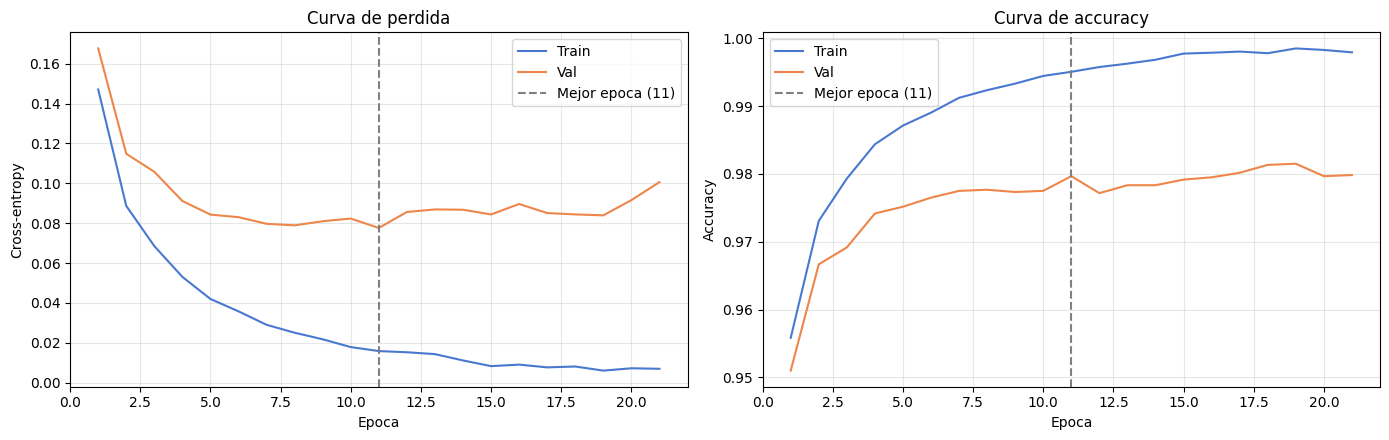

En la mejor epoca (11):
  train_loss=0.0158, val_loss=0.0776
  train_acc=0.9951, val_acc=0.9797
En la ultima epoca (21):
  train_loss=0.0069, val_loss=0.1006
  train_acc=0.9979, val_acc=0.9798
Epoca con mayor val_acc: 19 (0.9815)


In [12]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Val')
axes[0].axvline(best_epoch, color='gray', linestyle='--',
                label=f'Mejor epoca ({best_epoch})')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross-entropy')
axes[0].set_title('Curva de perdida')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'], label='Val')
axes[1].axvline(best_epoch, color='gray', linestyle='--',
                label=f'Mejor epoca ({best_epoch})')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('p2_04_curvas_entrenamiento.png', dpi=110, bbox_inches='tight')
plt.show()

last_epoch = len(history['train_loss'])
print(f"En la mejor epoca ({best_epoch}):")
print(f"  train_loss={history['train_loss'][best_epoch - 1]:.4f}, "
      f"val_loss={history['val_loss'][best_epoch - 1]:.4f}")
print(f"  train_acc={history['train_acc'][best_epoch - 1]:.4f}, "
      f"val_acc={history['val_acc'][best_epoch - 1]:.4f}")
print(f"En la ultima epoca ({last_epoch}):")
print(f"  train_loss={history['train_loss'][-1]:.4f}, "
      f"val_loss={history['val_loss'][-1]:.4f}")
print(f"  train_acc={history['train_acc'][-1]:.4f}, "
      f"val_acc={history['val_acc'][-1]:.4f}")
print(f"Epoca con mayor val_acc: {int(np.argmax(history['val_acc'])) + 1} "
      f"({max(history['val_acc']):.4f})")


**Diagnóstico.** Hay sobreajuste moderado, sin subajuste.

- *Sin subajuste*: la accuracy de train llega a 0.9951 en la mejor época y
  a 0.9979 al final. La red tiene capacidad de sobra para ajustar los
  datos.
- *Sobreajuste moderado*: en la mejor época, la pérdida de validación
  supera a la de train por 0.0618. La accuracy de train supera a la de
  validación por 1.54 puntos. Al final, las brechas son de 0.0937 y 1.81
  puntos. Desde la época 5, la pérdida de validación casi no baja (de
  0.084 a 0.078 en la época 11), y la de train sigue bajando. Después de la
  época 11, la de validación sube. El punto de sobreajuste está entre las
  épocas 5 y 11.
- *Regularización*: Dropout y Early Stopping limitan el sobreajuste, pero
  no lo eliminan.

**La pérdida y la accuracy no coinciden sobre la mejor época.** La accuracy
de validación llega a su máximo en la época 19 (0.9815), frente a 0.9797 en
la época 11. La diferencia es de 0.0018, unas 11 imágenes de 6000. La pérdida
castiga las predicciones seguras y equivocadas. La accuracy solo cuenta si la
clase más probable es correcta. Por eso no siempre coinciden.

Se mantiene el modelo de la época 11. La regla de parada se fijó antes de entrenar. Cambiarla después de ver la accuracy de validación es una decisión a posteriori. La sección 8.2 compara los dos criterios sin
ese sesgo.

## 6. Evaluación del modelo

### 6.1 Accuracy global y por clase en test

El modelo se evalúa sobre las 10000 imágenes de test, **una sola vez**, con
los pesos de la época 11 (sección 5). El test no se usa para tomar ninguna
decisión.

Se reportan:

- **Accuracy global**: fracción de imágenes bien clasificadas.
- **Accuracy por clase**: para cada dígito, la fracción de sus imágenes bien
  clasificadas. Es igual al recall de esa clase.
- **Precisión y F1 por clase**: la precisión indica cuántas de las
  imágenes que el modelo llama "dígito k" lo son realmente.
- **Intervalos de confianza de 95%** (método de Wilson). Test tiene unas
  1000 imágenes por clase. Una diferencia chica entre dos clases es, a veces, solo ruido de muestreo. El intervalo permite saber si una diferencia se
  distingue del ruido.

Como referencia, una regla que siempre predice la clase más frecuente da
una accuracy igual a la proporción de esa clase en test.

Accuracy global en test: 0.9802 (9802 de 10000; 198 errores)
Intervalo de confianza 95%: [0.9773, 0.9828]
Accuracy en validacion (mejor epoca): 0.9797
Referencia, clase mas frecuente siempre: 0.1135

        imagenes  accuracy  ic95_bajo  ic95_alto  precision      f1
digito                                                             
0            980    0.9929     0.9853     0.9965     0.9838  0.9883
1           1135    0.9903     0.9827     0.9946     0.9886  0.9894
2           1032    0.9797     0.9691     0.9867     0.9797  0.9797
3           1010    0.9842     0.9744     0.9902     0.9717  0.9779
4            982    0.9756     0.9639     0.9835     0.9856  0.9806
5            892    0.9709     0.9576     0.9800     0.9886  0.9796
6            958    0.9854     0.9756     0.9913     0.9823  0.9838
7           1028    0.9776     0.9667     0.9850     0.9710  0.9743
8            974    0.9682     0.9552     0.9775     0.9792  0.9737
9           1009    0.9752     0.9637     0.9832    

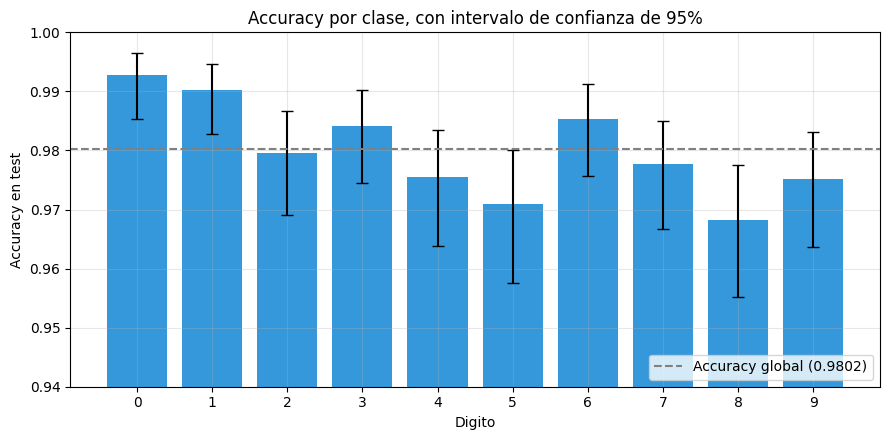

In [13]:
# Logits del modelo sobre test (unica evaluacion sobre este conjunto)
model.eval()
logits_batches, label_batches = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        logits_batches.append(model(x_batch.to(DEVICE)).cpu())
        label_batches.append(y_batch)
test_logits = torch.cat(logits_batches)
test_true = torch.cat(label_batches).numpy()
assert np.array_equal(test_true, y_test)

test_probs = torch.softmax(test_logits, dim=1).numpy()
test_preds = test_probs.argmax(axis=1)
test_confidence = test_probs.max(axis=1)


def wilson_interval(successes, total, z=1.96):
    # Intervalo de confianza de Wilson para una proporcion
    p = successes / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    half_width = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return center - half_width, center + half_width


n_correct = int((test_preds == test_true).sum())
test_accuracy = n_correct / len(test_true)
ci_low, ci_high = wilson_interval(n_correct, len(test_true))
majority_baseline = np.bincount(test_true).max() / len(test_true)

print(f"Accuracy global en test: {test_accuracy:.4f} "
      f"({n_correct} de {len(test_true)}; {len(test_true) - n_correct} errores)")
print(f"Intervalo de confianza 95%: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Accuracy en validacion (mejor epoca): {history['val_acc'][best_epoch - 1]:.4f}")
print(f"Referencia, clase mas frecuente siempre: {majority_baseline:.4f}")

# Metricas por clase
class_rows = []
for digit in range(10):
    is_digit = test_true == digit
    predicted_digit = test_preds == digit
    hits = int((is_digit & predicted_digit).sum())
    accuracy_k = hits / is_digit.sum()
    precision_k = hits / predicted_digit.sum()
    f1_k = 2 * precision_k * accuracy_k / (precision_k + accuracy_k)
    low, high = wilson_interval(hits, int(is_digit.sum()))
    class_rows.append({'digito': digit, 'imagenes': int(is_digit.sum()),
                       'accuracy': accuracy_k, 'ic95_bajo': low, 'ic95_alto': high,
                       'precision': precision_k, 'f1': f1_k})
per_class = pd.DataFrame(class_rows).set_index('digito')
print()
print(per_class.round(4).to_string())
print(f"\nMejor clase: {per_class['accuracy'].idxmax()} "
      f"({per_class['accuracy'].max():.4f}), peor clase: "
      f"{per_class['accuracy'].idxmin()} ({per_class['accuracy'].min():.4f})")

# Las 10 accuracies por clase, son distintas? Prueba chi-cuadrado de homogeneidad
hits_per_class = np.array([int(((test_true == d) & (test_preds == d)).sum())
                           for d in range(10)])
images_per_class = np.bincount(test_true, minlength=10)
chi2_stat, chi2_p, _, _ = chi2_contingency(
    np.vstack([hits_per_class, images_per_class - hits_per_class]).T)
print(f"\nPrueba chi-cuadrado (las 10 accuracies son iguales): p = {chi2_p:.4f}")

# Mejor contra peor clase (elegidas despues de ver los datos): prueba exacta de
# Fisher, con el umbral de Bonferroni para las 45 comparaciones posibles
best_digit = int(per_class['accuracy'].idxmax())
worst_digit = int(per_class['accuracy'].idxmin())
_, fisher_p = fisher_exact([
    [hits_per_class[best_digit], images_per_class[best_digit] - hits_per_class[best_digit]],
    [hits_per_class[worst_digit], images_per_class[worst_digit] - hits_per_class[worst_digit]]])
print(f"Clase {best_digit} contra clase {worst_digit} (Fisher): p = {fisher_p:.5f}; "
      f"umbral de Bonferroni para 45 pares: {0.05 / 45:.5f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
errors_low = per_class['accuracy'] - per_class['ic95_bajo']
errors_high = per_class['ic95_alto'] - per_class['accuracy']
ax.bar(per_class.index, per_class['accuracy'], color='#3498db',
       yerr=[errors_low, errors_high], capsize=4)
ax.axhline(test_accuracy, color='gray', linestyle='--',
           label=f'Accuracy global ({test_accuracy:.4f})')
ax.set_ylim(0.94, 1.0)
ax.set_xticks(range(10))
ax.set_xlabel('Digito')
ax.set_ylabel('Accuracy en test')
ax.set_title('Accuracy por clase, con intervalo de confianza de 95%')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('p2_05_accuracy_por_clase.png', dpi=110, bbox_inches='tight')
plt.show()


**Accuracy global.** El modelo acierta 9802 de 10000 imágenes de test. La
accuracy es 0.9802, con 198 errores. El intervalo de confianza de 95% es
[0.9773, 0.9828]. La accuracy de validación (0.9797) cae dentro de ese
intervalo, así que las dos estimaciones son consistentes. La referencia de
la clase más frecuente da 0.1135, muy lejos de 0.9802.

**Accuracy por clase.** Va de 0.9682 (dígito 8) a 0.9929 (dígito 0). Los
tres dígitos más difíciles son el 8 (0.9682), el 5 (0.9709) y el 9
(0.9752). Quedan entre 0.50 y 1.20 puntos por debajo del global. Los más
fáciles son el 0 (0.9929) y el 1 (0.9903).

**Las diferencias entre clases son reales.** La prueba chi-cuadrado
rechaza que las 10 accuracies sean iguales (p = 0.0004). La mejor y la
peor clase difieren de forma clara. La prueba de Fisher da p = 0.00006,
menor que el umbral de Bonferroni (0.0011). Ese umbral corrige por haber
elegido las dos clases extremas después de ver los datos. Los intervalos de
las clases intermedias se superponen mucho, así que no se ordenan entre sí.

**La cantidad de imágenes no explica todo.** El 5 es la clase con menos
imágenes (892 en test), y su accuracy (0.9709) es la segunda más baja. Pero
la peor clase, el 8, tiene 974 imágenes, y la mejor, el 0, tiene 980. No se
probó ninguna causa de las diferencias.

**Precisión.** La más baja es la del 7 (0.9710). El modelo llama "7" a
imágenes de otras clases, sobre todo 9, 8 y 3 (sección 7).

**¿Es adecuada la accuracy?** Sí, como métrica global, con tres cautelas.

- Las clases están balanceadas (razón 1.24). La accuracy no se infla por
  ignorar una clase, como pasaba en el Problema 1. La referencia de 0.1135
  lo confirma.
- La accuracy global oculta diferencias reales entre clases, de hasta 2.5
  puntos. Por eso también se reporta la accuracy por clase.
- La accuracy no dice nada sobre la confianza de las predicciones. Un modelo con 0.980 da a veces una confianza mayor que 0.99 a un error (sección 7.3). Tampoco distingue tipos de error: todos pesan igual, y en este
  problema no se definió un costo distinto para cada tipo.

## 7. Matriz de confusión y análisis de errores

### 7.1 Matriz de confusión

Se muestra la matriz de confusión de test. Las filas son la clase real y
las columnas la clase predicha. Como la diagonal concentra casi todas las
imágenes y tapa los errores, se hacen dos paneles:

- **Izquierda**: la matriz completa. El color es el porcentaje dentro de
  cada fila, y el número es la cantidad de imágenes.
- **Derecha**: solo los errores (fuera de la diagonal), con su propia
  escala de color.

Después se listan las confusiones más frecuentes. Una confusión "real -> predicha"
es un error de una dirección. También se suman las dos direcciones de cada
par de dígitos.

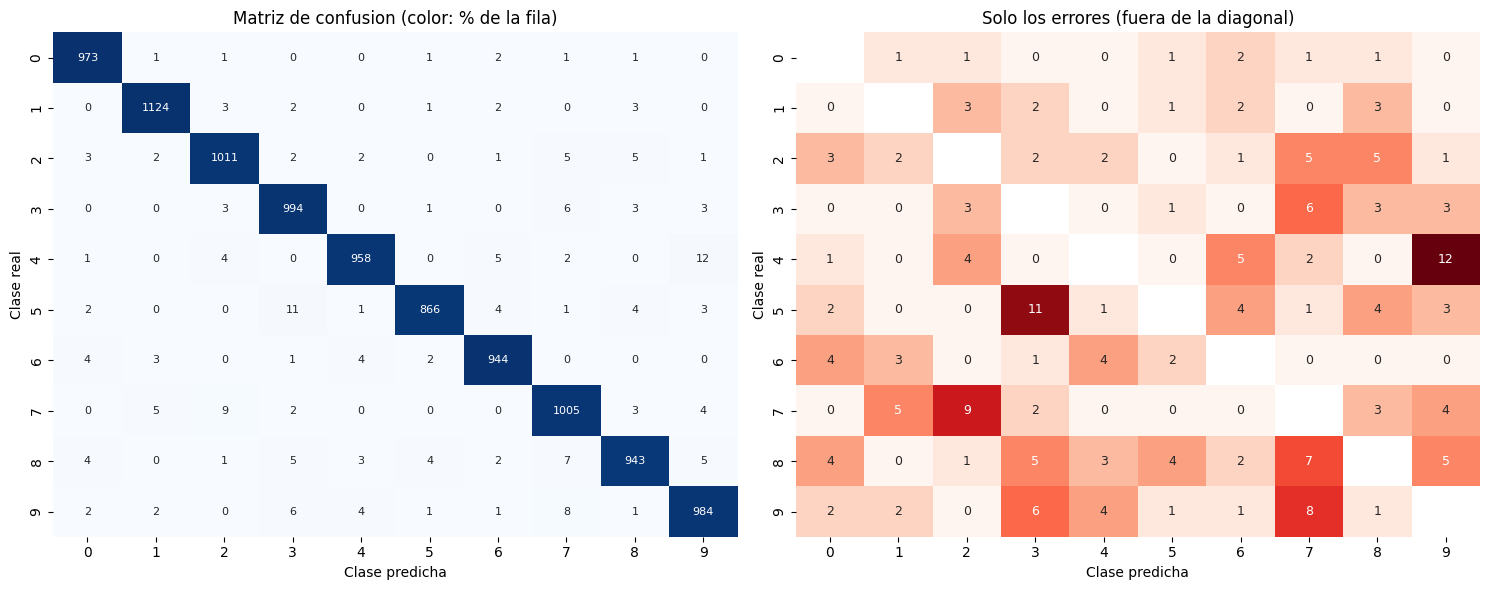

Confusiones en una direccion (real -> predicha):
  4 -> 9: 12
  5 -> 3: 11
  7 -> 2: 9
  9 -> 7: 8
  8 -> 7: 7
  3 -> 7: 6
  9 -> 3: 6
  2 -> 7: 5
  2 -> 8: 5
  4 -> 6: 5

Pares de digitos, sumando las dos direcciones:
  4 <-> 9: 16
  2 <-> 7: 14
  3 <-> 5: 12
  7 <-> 9: 12
  7 <-> 8: 10
  3 <-> 9: 9

Errores totales: 198


In [14]:
cm = confusion_matrix(test_true, test_preds)
row_percent = cm / cm.sum(axis=1, keepdims=True) * 100
errors_only = np.where(np.eye(10, dtype=bool), 0, cm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(row_percent, annot=cm, fmt='d', cmap='Blues', vmin=0, vmax=100,
            cbar=False, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Matriz de confusion (color: % de la fila)')
sns.heatmap(errors_only, annot=True, fmt='d', cmap='Reds', cbar=False,
            mask=np.eye(10, dtype=bool), ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Solo los errores (fuera de la diagonal)')
for ax in axes:
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')
    ax.grid(False)
plt.tight_layout()
plt.savefig('p2_06_matriz_confusion.png', dpi=110, bbox_inches='tight')
plt.show()

# Confusiones mas frecuentes, en una direccion y por par de digitos
directed = [(true_digit, pred_digit, int(errors_only[true_digit, pred_digit]))
            for true_digit in range(10) for pred_digit in range(10)
            if true_digit != pred_digit]
top_directed = sorted(directed, key=lambda item: -item[2])[:10]
print("Confusiones en una direccion (real -> predicha):")
for true_digit, pred_digit, count in top_directed:
    print(f"  {true_digit} -> {pred_digit}: {count}")

pair_totals = {}
for true_digit, pred_digit, count in directed:
    pair = tuple(sorted((true_digit, pred_digit)))
    pair_totals[pair] = pair_totals.get(pair, 0) + count
print("\nPares de digitos, sumando las dos direcciones:")
for pair, count in sorted(pair_totals.items(), key=lambda item: -item[1])[:6]:
    print(f"  {pair[0]} <-> {pair[1]}: {count}")
print(f"\nErrores totales: {int(errors_only.sum())}")


Casi todas las imágenes están en la diagonal. Hay 198 errores, repartidos
en muchas celdas de pocas imágenes. La más grande tiene 12 (4 -> 9). Le
siguen 5 -> 3 (11), 7 -> 2 (9) y 9 -> 7 (8).

**Pares más confundidos.** Al sumar las dos direcciones, el par 4-9 es el
mayor (16 imágenes). Siguen 2-7 (14), 3-5 y 7-9 (12 cada uno), 7-8 (10) y
3-9 (9). Son dígitos de forma parecida. Las imágenes de la sección 7.2
muestran por qué.

**Cautela con los conteos.** Cada par tiene entre 9 y 16 imágenes. El
orden entre los pares no es fiable. En la versión anterior de este
notebook, que mezclaba los datos con otro generador, el par mayor era 4-9
(19) y el segundo 2-7 (14). En una corrida anterior en CPU, el orden era el
inverso: 2-7 (16) y 4-9 (15). Los dos pares están arriba en las tres
corridas, pero el orden exacto cambia.

**Asimetría.** Algunas confusiones no son simétricas. La confusión 4 -> 9
ocurre 12 veces y 9 -> 4 ocurre 4. La confusión 5 -> 3 ocurre 11 veces y
3 -> 5 ocurre 1. No se probó si la asimetría es real.

**Los dígitos 0 y 1.** Ninguno de los seis pares más confundidos incluye al
0 ni al 1. Son los dígitos con mayor accuracy (0.9929 y 0.9903). Es
coherente con que su forma, un óvalo cerrado y un trazo recto, se parezca
poco a la de otros dígitos.

### 7.2 Ejemplos de las confusiones más frecuentes

Para explicar las confusiones por la forma de los dígitos, se miran
imágenes reales. Para cada una de las 4 confusiones más frecuentes en una
dirección, se muestran 6 imágenes. Son las primeras 6 por orden de índice en
test, sin selección, para no elegir solo los casos que encajan con una
explicación. El título indica la clase real, la predicha y la
probabilidad que la red asigna a la clase predicha.

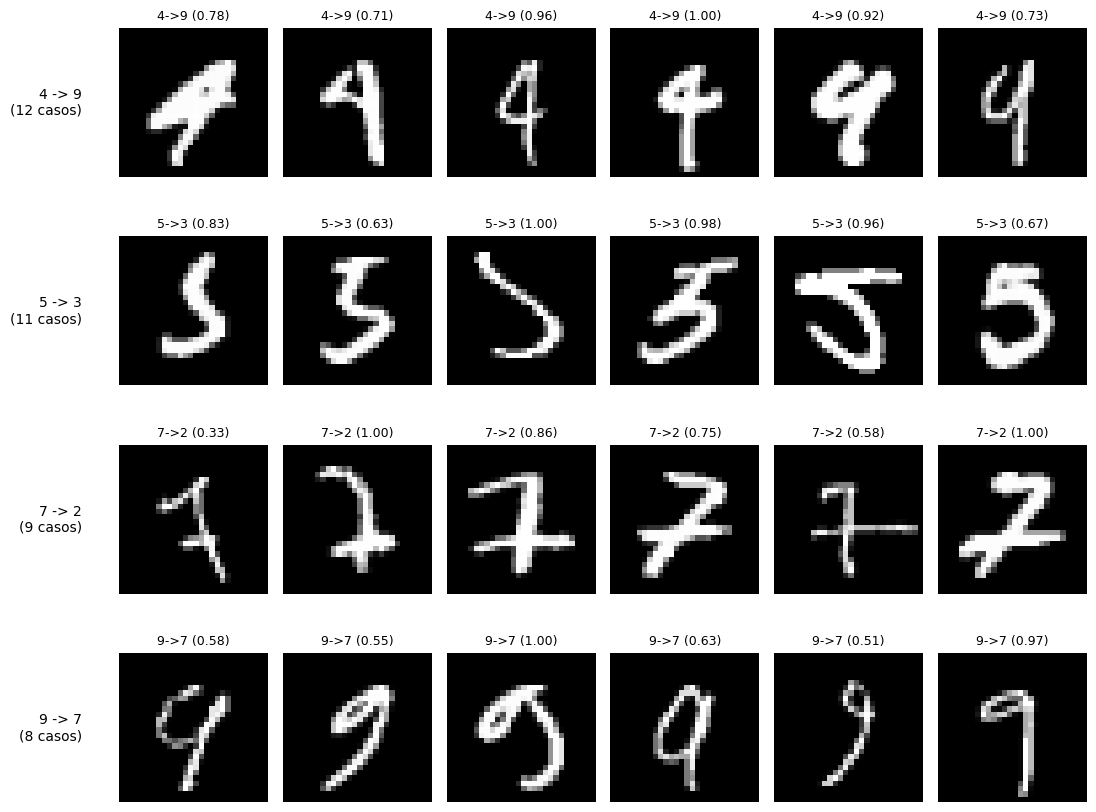

In [15]:
top_four = top_directed[:4]
fig, axes = plt.subplots(len(top_four), 6, figsize=(11, 2.0 * len(top_four) + 0.6))
for row, (true_digit, pred_digit, count) in enumerate(top_four):
    indices = np.where((test_true == true_digit) & (test_preds == pred_digit))[0][:6]
    for col in range(6):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(indices):
            index = indices[col]
            ax.imshow(X_test[index], cmap='gray')
            ax.set_title(f"{true_digit}->{pred_digit} ({test_confidence[index]:.2f})",
                         fontsize=9)
    axes[row, 0].text(-0.25, 0.5, f"{true_digit} -> {pred_digit}\n({count} casos)",
                      transform=axes[row, 0].transAxes, ha='right', va='center',
                      fontsize=10)
plt.tight_layout()
plt.savefig('p2_07_ejemplos_confusiones.png', dpi=110, bbox_inches='tight')
plt.show()


Las imágenes muestran formas parecidas entre la clase real y la predicha.
Lo que sigue es una interpretación visual de las 24 imágenes. Son las
primeras por índice, no una selección.

- **4 -> 9.** En varios cuatros, los dos trazos de arriba se juntan y forman
  un lazo cerrado. Con el lazo cerrado y el trazo vertical a la derecha, la
  forma es la de un 9. La cuarta imagen es un 4 abierto y claro, y la red
  igual lo llama 9 con confianza 1.00.
- **5 -> 3.** En varios cincos, el trazo vertical de arriba a la izquierda es
  corto o casi no se ve. Sin ese trazo, la barra de arriba y la panza forman
  un 3. La tercera imagen no tiene barra superior. La cuarta parece un 3
  también para una persona.
- **7 -> 2.** Varios sietes tienen una barra horizontal que cruza el trazo
  vertical, o un trazo corto al pie. Esa barra baja se parece a la base de
  un 2. La segunda, la cuarta y la sexta imagen tienen forma de Z, como un 2.
- **9 -> 7.** En varios nueves, el lazo de arriba está abierto o es muy chico.
  Queda un trazo superior y un trazo largo hacia abajo, como en un 7.

Las confianzas de estas 24 imágenes son variadas. 10 superan 0.9. Las otras
14 van de 0.33 a 0.86, así que en muchas la red dudaba. Son explicaciones
visuales y no se probaron: no se sabe si la red usa esos rasgos. Otros
factores, como el grosor o la inclinación, no se evaluaron.

### 7.3 Errores con alta confianza

El enunciado pide mostrar al menos 5 imágenes mal clasificadas **con alta
confianza**. Son las imágenes en las que la red se equivoca y, además,
asigna una probabilidad muy alta a la clase equivocada. Los errores se
ordenan por la probabilidad de la clase predicha, y se muestran los 10
primeros. También se mide cuántos errores tienen una confianza mayor que 0.9, y cuántos errores detecta un umbral de confianza de 0.9.

Confianza media en aciertos: 0.9928
Confianza media en errores:  0.7597
Errores con confianza > 0.9: 70 de 198
Errores con confianza > 0.99: 22 de 198

indice | real -> predicha | confianza | prob. de la clase real
  1681 | 3 -> 7 | 0.9999 | 0.0001
  3520 | 6 -> 4 | 0.9999 | 0.0000
  2939 | 9 -> 7 | 0.9996 | 0.0000
  9009 | 7 -> 2 | 0.9994 | 0.0002
  1530 | 8 -> 7 | 0.9994 | 0.0001
  9729 | 5 -> 6 | 0.9993 | 0.0006
  5331 | 1 -> 6 | 0.9990 | 0.0005
  1226 | 7 -> 2 | 0.9987 | 0.0002
  1901 | 9 -> 4 | 0.9985 | 0.0015
   582 | 8 -> 2 | 0.9980 | 0.0008


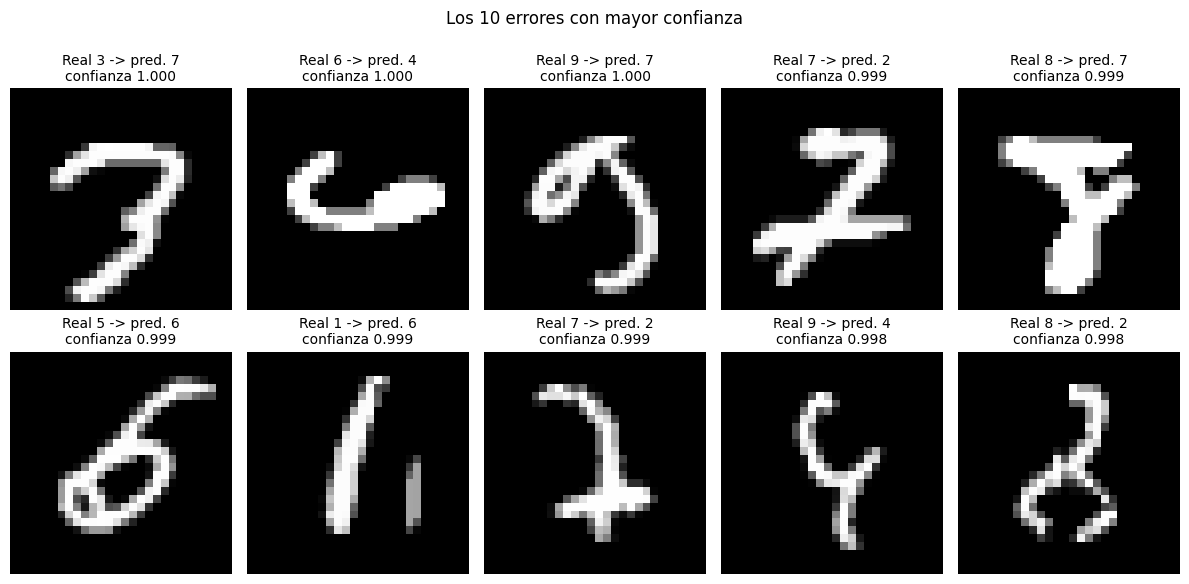


Imagenes con confianza <= 0.9: 333 de 10000
  errores dentro de ese grupo: 128 de 198


In [16]:
wrong_indices = np.where(test_preds != test_true)[0]
order = wrong_indices[np.argsort(-test_confidence[wrong_indices])]
top_confident_errors = order[:10]

correct_mask = test_preds == test_true
print(f"Confianza media en aciertos: {test_confidence[correct_mask].mean():.4f}")
print(f"Confianza media en errores:  {test_confidence[wrong_indices].mean():.4f}")
print(f"Errores con confianza > 0.9: "
      f"{int((test_confidence[wrong_indices] > 0.9).sum())} de {len(wrong_indices)}")
print(f"Errores con confianza > 0.99: "
      f"{int((test_confidence[wrong_indices] > 0.99).sum())} de {len(wrong_indices)}")

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
print("\nindice | real -> predicha | confianza | prob. de la clase real")
for ax, index in zip(axes.flat, top_confident_errors):
    ax.imshow(X_test[index], cmap='gray')
    ax.set_title(f"Real {test_true[index]} -> pred. {test_preds[index]}\n"
                 f"confianza {test_confidence[index]:.3f}", fontsize=10)
    ax.axis('off')
    print(f"{index:6d} | {test_true[index]} -> {test_preds[index]} | "
          f"{test_confidence[index]:.4f} | {test_probs[index, test_true[index]]:.4f}")
fig.suptitle("Los 10 errores con mayor confianza", y=1.0)
plt.tight_layout()
plt.savefig('p2_08_errores_alta_confianza.png', dpi=110, bbox_inches='tight')
plt.show()

# Utilidad de la confianza para detectar errores (umbral 0.9, fijado de antemano)
low_confidence = test_confidence <= 0.9
errors_with_low_confidence = int((low_confidence & ~correct_mask).sum())
print(f"\nImagenes con confianza <= 0.9: {int(low_confidence.sum())} de {len(test_true)}")
print(f"  errores dentro de ese grupo: {errors_with_low_confidence} de "
      f"{len(wrong_indices)}")


**La confianza es informativa, pero no es confiable.** La confianza media
es 0.9928 en los aciertos y 0.7597 en los errores. La red duda más cuando
se equivoca. Aun así, 70 de los 198 errores (35%) tienen confianza mayor
que 0.9, y 22 (11%) mayor que 0.99.

**Qué muestran los 10 errores más seguros** (interpretación visual de las
imágenes):

- Dos son sietes escritos con una barra que cruza el trazo, o con forma de
  Z, que la red llama 2. Es el mismo patrón de la sección 7.2.
- Varios son ambiguos, incluso para una persona. Hay un 6 caído de lado (predicho 4) y un 1 con un segundo trazo suelto (predicho 6). Hay también un 3 que parece un 7, y un 8 sin lazos visibles (predicho 7).
- Otros tienen un rasgo de la clase predicha. Un 9 con el lazo abierto se predice 7, y otro 9 se predice 4. Un 5 con la panza cerrada se predice 6, y un 8 con el lazo de arriba abierto se predice 2.
- No es posible verificar las etiquetas. En algunos casos, como el 6 caído, la
  etiqueta es difícil de comprobar.

**Por qué hay confianza alta en imágenes raras.** Softmax reparte siempre
una probabilidad total de 1 entre las 10 clases. La red no tiene una
salida "no sé". Ante una imagen atípica, como un dígito girado, igual
asigna casi toda la probabilidad a una clase.

**Uso práctico.** Con el umbral de 0.9, fijado antes de mirar los
resultados, 333 imágenes (3.3% de test) tienen confianza baja. Esas 333
contienen 128 de los 198 errores (65%), y 205 estaban bien clasificadas.
Si se revisan solo esas imágenes, se encuentra la mayoría de los errores. Los otros
70 errores quedan sin señalar.

## 8. Limitaciones del MLP frente a datos de imagen

El enunciado pide reflexionar sobre las limitaciones de los MLP con
imágenes. En lugar de solo describirlas, se mide una de ellas. Después
se mide también si las decisiones de diseño importaron (sección 8.2).
La reflexión completa está en la sección 8.3.

### 8.1 Experimento: sensibilidad a desplazamientos

**Apunte de la Unidad 5, sección 5.1.2**

> En una red densa, el conocimiento espacial no se transfiere: un patrón
> aprendido en una región no sirve para reconocerlo en otra posición.
>
> — Unidad 5 - Redes Convolucionales - Parte 1, seccion 5.1.2

El apunte dice que aplanar la imagen destruye la estructura espacial. Un MLP
recibe 784 valores sin saber cuáles píxeles son vecinos. Si un dígito se
mueve, cambian los píxeles que se encienden, y la red no reconoce que es el
mismo patrón.

**Predicción, escrita antes de medir:** si la afirmación es cierta, la
accuracy del modelo debe bajar a medida que se desplazan los dígitos. La causa
es que el entrenamiento solo vio dígitos centrados.

Protocolo:

- Se desplazan las imágenes de test 1, 2, 3 y 4 píxeles en cuatro
  direcciones (derecha, izquierda, abajo, arriba). El relleno es cero, sin
  envolver la imagen. El desplazamiento 0 es la accuracy de la sección 6.1.
- Se evalúa el **mismo modelo**, sin reentrenar y sin ajustar nada. Este
  resultado no se usa para elegir el modelo.
- Se mide cuántas imágenes pierden parte del trazo al desplazarse. Si un
  desplazamiento recorta el dígito, la caída de accuracy tiene otra causa,
  además de la posición. Como **control**, se repite la medición solo sobre
  las imágenes cuyo trazo sobrevive intacto. Después se compara con la
  accuracy de esas mismas imágenes sin desplazar. Esa diferencia mide el
  efecto de la posición sola.
- Se muestra la distribución de clases predichas con un desplazamiento de 3
  píxeles. Así se ve si la red predice al azar o colapsa hacia pocas clases.

Accuracy en test con las imagenes desplazadas:
direccion  ninguna  derecha  izquierda   abajo  arriba  promedio
pixeles                                                         
0           0.9802      NaN        NaN     NaN     NaN    0.9802
1              NaN   0.9699     0.9647  0.9621  0.9600    0.9642
2              NaN   0.8818     0.8422  0.8366  0.8555    0.8540
3              NaN   0.6459     0.6281  0.5406  0.5664    0.5953
4              NaN   0.4097     0.4253  0.2473  0.2592    0.3354

Imagenes con trazo perdido por el desplazamiento (%):
direccion  abajo  arriba  derecha  izquierda
pixeles                                     
0            NaN     NaN      NaN        NaN
1           0.90    0.00     0.16       0.02
2           9.98    0.45     1.41       0.18
3          23.70    5.86     5.94       0.93
4          50.37   14.53    16.49       4.32

Control sobre imagenes con el trazo intacto:
 pixeles direccion  n_intactas  acc_intactas_sin_desplazar  acc_intactas_desplazad

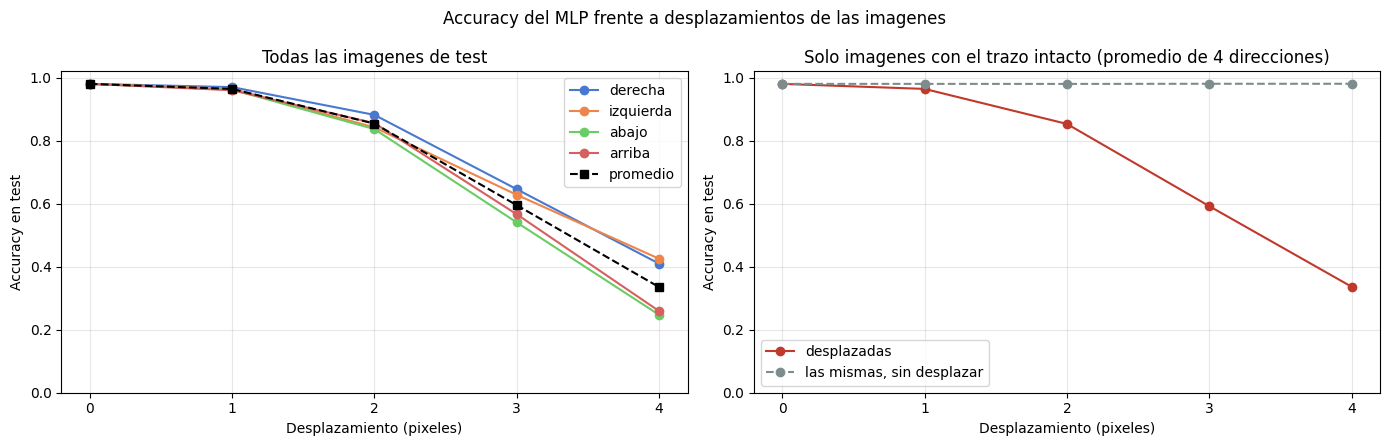

In [17]:
def shift_images(images, dx, dy):
    # Desplaza un lote (N, 28, 28): dx > 0 a la derecha, dy > 0 hacia abajo.
    # El relleno es cero y no se envuelve la imagen.
    height, width = images.shape[1:]
    shifted = np.zeros_like(images)
    src_x = slice(max(0, -dx), min(width, width - dx))
    dst_x = slice(max(0, dx), min(width, width + dx))
    src_y = slice(max(0, -dy), min(height, height - dy))
    dst_y = slice(max(0, dy), min(height, height + dy))
    shifted[:, dst_y, dst_x] = images[:, src_y, src_x]
    return shifted


def predict_classes(images):
    # Clases predichas por el modelo entrenado (seccion 5) para un lote uint8
    model.eval()
    features = torch.from_numpy(flatten_and_normalize(images)).to(DEVICE)
    with torch.no_grad():
        return model(features).argmax(dim=1).cpu().numpy()


# Chequeo de la funcion con una imagen sintetica de un solo pixel (fila 10, col 10)
single_pixel = np.zeros((1, 28, 28), dtype=np.uint8)
single_pixel[0, 10, 10] = 255
expected_positions = {
    (3, 0): (10, 13), (-3, 0): (10, 7), (0, 3): (13, 10), (0, -3): (7, 10)}
for (shift_x, shift_y), (row_expected, col_expected) in expected_positions.items():
    moved = shift_images(single_pixel, shift_x, shift_y)
    assert moved.sum() == 255 and moved[0, row_expected, col_expected] == 255
# Un pixel en el borde sale del cuadro al desplazarlo hacia afuera
border_pixel = np.zeros((1, 28, 28), dtype=np.uint8)
border_pixel[0, 5, 27] = 255
assert shift_images(border_pixel, 1, 0).sum() == 0
assert np.array_equal(shift_images(X_test, 0, 0), X_test)

directions = {'derecha': (1, 0), 'izquierda': (-1, 0),
              'abajo': (0, 1), 'arriba': (0, -1)}
shift_sizes = [0, 1, 2, 3, 4]
ink_original = X_test.reshape(len(X_test), -1).astype(np.int64).sum(axis=1)

shift_rows, predictions_by_shift = [], {}
for size in shift_sizes:
    for direction, (unit_x, unit_y) in directions.items():
        if size == 0 and direction != 'derecha':
            continue   # el desplazamiento 0 es igual en todas las direcciones
        shifted = shift_images(X_test, unit_x * size, unit_y * size)
        predictions = predict_classes(shifted)
        hits = int((predictions == y_test).sum())
        low, high = wilson_interval(hits, len(y_test))
        ink_shifted = shifted.reshape(len(shifted), -1).astype(np.int64).sum(axis=1)
        # Control: imagenes cuyo trazo sobrevive intacto al desplazamiento
        intact = ink_shifted == ink_original
        shift_rows.append({
            'pixeles': size,
            'direccion': 'ninguna' if size == 0 else direction,
            'accuracy': hits / len(y_test), 'ic95_bajo': low, 'ic95_alto': high,
            'imagenes_con_trazo_perdido_%': (~intact).mean() * 100,
            'n_intactas': int(intact.sum()),
            'acc_intactas_desplazadas': (predictions[intact] == y_test[intact]).mean(),
            'acc_intactas_sin_desplazar': (test_preds[intact] == y_test[intact]).mean(),
        })
        predictions_by_shift.setdefault(size, []).append(predictions)

shift_results = pd.DataFrame(shift_rows)
accuracy_table = shift_results.pivot_table(index='pixeles', columns='direccion',
                                           values='accuracy')
accuracy_table['promedio'] = shift_results.groupby('pixeles')['accuracy'].mean()
accuracy_table.loc[0, ['derecha', 'izquierda', 'abajo', 'arriba']] = np.nan
ink_table = shift_results.pivot_table(
    index='pixeles', columns='direccion', values='imagenes_con_trazo_perdido_%')

print("Accuracy en test con las imagenes desplazadas:")
print(accuracy_table[['ninguna', 'derecha', 'izquierda', 'abajo', 'arriba',
                      'promedio']].round(4).to_string())
print("\nImagenes con trazo perdido por el desplazamiento (%):")
print(ink_table.drop(columns='ninguna').round(2).to_string())
assert abs(accuracy_table.loc[0, 'ninguna'] - test_accuracy) < 1e-12

# Control: solo las imagenes cuyo trazo sobrevive intacto al desplazamiento.
# Se compara contra las mismas imagenes sin desplazar.
control = shift_results[shift_results['pixeles'] > 0].copy()
control['caida_por_posicion'] = (control['acc_intactas_sin_desplazar']
                                 - control['acc_intactas_desplazadas'])
print("\nControl sobre imagenes con el trazo intacto:")
print(control[['pixeles', 'direccion', 'n_intactas', 'acc_intactas_sin_desplazar',
               'acc_intactas_desplazadas', 'caida_por_posicion']].round(4).to_string(index=False))
control_mean = control.groupby('pixeles')[
    ['acc_intactas_sin_desplazar', 'acc_intactas_desplazadas']].mean()
print("\nPromedio de las 4 direcciones:")
print(control_mean.round(4).to_string())

# Clases predichas con desplazamiento de 3 pixeles, contra sin desplazar
pooled_predictions = np.concatenate(predictions_by_shift[3])
predicted_share = pd.DataFrame({
    'sin_desplazar_%': np.bincount(test_preds, minlength=10) / len(test_preds) * 100,
    'desplazado_3px_%': np.bincount(pooled_predictions, minlength=10)
                        / len(pooled_predictions) * 100,
}).round(1)
predicted_share.index.name = 'clase_predicha'
print("\nClases predichas (las 4 direcciones juntas para 3 px):")
print(predicted_share.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for direction in directions:
    subset = shift_results[shift_results['direccion'] == direction]
    axes[0].plot([0] + subset['pixeles'].tolist(),
                 [test_accuracy] + subset['accuracy'].tolist(),
                 marker='o', label=direction)
axes[0].plot(shift_sizes, accuracy_table['promedio'].values, color='black',
             linestyle='--', marker='s', label='promedio')
axes[0].set_title('Todas las imagenes de test')
axes[1].plot([0] + control_mean.index.tolist(),
             [test_accuracy] + control_mean['acc_intactas_desplazadas'].tolist(),
             marker='o', color='#c0392b', label='desplazadas')
axes[1].plot([0] + control_mean.index.tolist(),
             [test_accuracy] + control_mean['acc_intactas_sin_desplazar'].tolist(),
             marker='o', color='#7f8c8d', linestyle='--', label='las mismas, sin desplazar')
axes[1].set_title('Solo imagenes con el trazo intacto (promedio de 4 direcciones)')
for ax in axes:
    ax.set_xticks(shift_sizes)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Desplazamiento (pixeles)')
    ax.set_ylabel('Accuracy en test')
    ax.legend()
fig.suptitle('Accuracy del MLP frente a desplazamientos de las imagenes')
plt.tight_layout()
plt.savefig('p2_09_sensibilidad_desplazamiento.png', dpi=110, bbox_inches='tight')
plt.show()


**La predicción se cumple: la accuracy baja al desplazar las imágenes.**
Promediando las 4 direcciones, pasa de 0.9802 sin desplazar a 0.9642 con 1
píxel, 0.8540 con 2, 0.5953 con 3 y 0.3354 con 4. Eso es una caída de 1.6,
12.6, 38.5 y 64.5 puntos. Un desplazamiento de 2 píxeles, menos del 8% del
ancho de la imagen, ya cuesta 12.6 puntos.

**El control descarta que la causa sea el trazo recortado.** Con 1 o 2
píxeles, pocas imágenes pierden trazo (hasta 1.41% hacia los lados y 9.98%
hacia abajo con 2 píxeles). Con 3 y 4 píxeles, más: 23.70% y 50.37% hacia
abajo. Pero la accuracy cae casi igual sobre las imágenes cuyo trazo
sobrevive intacto. En promedio es 0.9642, 0.8531, 0.5922 y 0.3365. Las
mismas imágenes sin desplazar dan entre 0.9800 y 0.9805. La caída se debe a
la posición, no al recorte. Con 3 píxeles, la caída por posición va de 34.2 a
44.7 puntos según la dirección.

**Direcciones.** Hacia abajo y hacia arriba la caída es mayor que hacia los
lados. Con 3 píxeles, la accuracy es 0.5406 y 0.5664 en vertical, y 0.6459
y 0.6281 en horizontal. El control sobre imágenes intactas da la misma
diferencia, así que el recorte no la explica. Esta diferencia queda sin explicar.

**Clases predichas con 3 píxeles.** La red no colapsa hacia una sola clase,
pero se inclina. Predice más el 7 (14.7%), el 2 (13.9%) y el 3 (12.1%).
Predice menos el 1 (6.0%), el 0 (6.0%) y el 4 (8.5%). Sin desplazar, todas
las clases están entre 8.8% y 11.4%.

**Conclusión.** El MLP no tiene tolerancia a la posición incorporada. El
resultado respalda la afirmación del apunte de la Unidad 5: lo aprendido en
una posición no se transfiere a otra. Cautelas: los desplazamientos son
sintéticos y parten de dígitos centrados. El relleno es cero. El modelo se
entrenó solo con dígitos centrados, sin aumento de datos. No se probó un MLP
entrenado con ejemplos desplazados.

#### Ejemplos de imágenes desplazadas

Para ver el efecto sobre imágenes concretas, se desplazan hacia la derecha las dos primeras imágenes de test (índices 0 y 1, sin selección). Se muestran la clase que predice el modelo y su confianza.

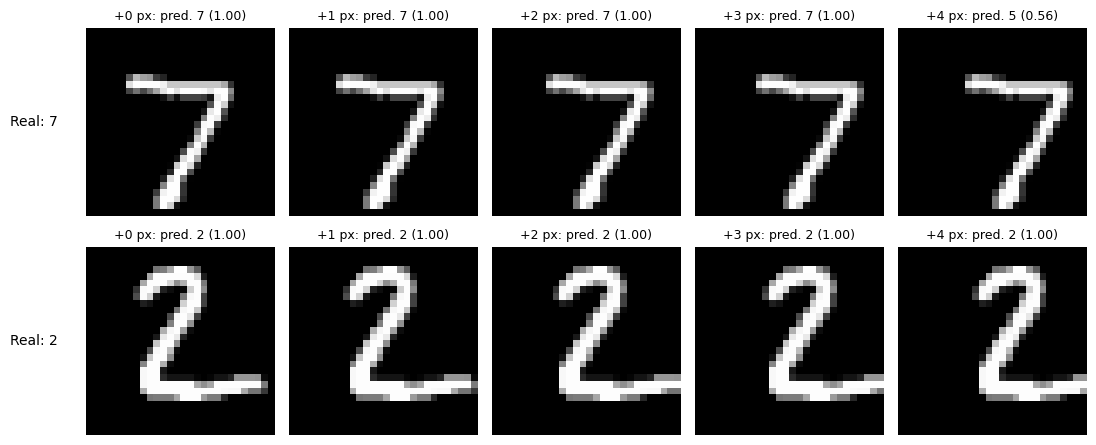

In [18]:
example_indices = [0, 1]
fig, axes = plt.subplots(len(example_indices), len(shift_sizes), figsize=(11, 4.6))
for row, index in enumerate(example_indices):
    for col, size in enumerate(shift_sizes):
        shifted = shift_images(X_test[index:index + 1], size, 0)
        features = torch.from_numpy(flatten_and_normalize(shifted)).to(DEVICE)
        with torch.no_grad():
            probabilities = torch.softmax(model(features), dim=1)[0].cpu().numpy()
        axes[row, col].imshow(shifted[0], cmap='gray')
        axes[row, col].set_title(
            f"+{size} px: pred. {probabilities.argmax()} ({probabilities.max():.2f})",
            fontsize=9)
        axes[row, col].axis('off')
    axes[row, 0].text(-0.15, 0.5, f"Real: {y_test[index]}", transform=axes[row, 0].transAxes,
                      ha='right', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('p2_10_ejemplos_desplazamiento.png', dpi=110, bbox_inches='tight')
plt.show()


La imagen 0 (un 7) se predice bien hasta 3 píxeles, con confianza 1.00. Con
4 píxeles, la red la llama 5, con confianza 0.56. La imagen 1 (un 2) se
predice bien en todos los desplazamientos, con confianza 1.00, aunque su
trazo inferior llega al borde derecho.

Estas dos imágenes no son representativas. Se tomaron sin selección. El 7
resiste hasta 3 píxeles y el 2 resiste los 4. La accuracy global con 4
píxeles es 0.34, así que muchas otras imágenes fallan antes. La tolerancia cambia de una
imagen a otra. La evidencia es la curva de la sección anterior, no estos
dos ejemplos.

### 8.2 Ablación sobre validación: decisiones de diseño

En el Problema 1, al medir las decisiones de diseño, varias no mostraron el
efecto que se había argumentado. Aquí se hace lo mismo con las decisiones
del Problema 2 que no se midieron antes. Esas decisiones son el **tamaño** de
la red, el **Dropout** y el **criterio de parada**. Todo el protocolo usa solo
train y validación. El test no se toca.

Variantes (se cambia una decisión a la vez):

- **Base**: 256-128 neuronas, Dropout 0.3.
- **Dropout 0.0** y **Dropout 0.5**.
- **Tamaño 64-32** y **tamaño 512-256**.

Protocolo: 5 semillas por variante. La semilla 42 de la variante base debe
reproducir la sección 5, y esto se verifica. Cada corrida fija la semilla de
PyTorch y crea su propio loader de train, con un generador que usa la misma
semilla. Ningún otro paso consume el azar global (sección 4.1). Por eso la
semilla 42 reproduce la sección 5 por construcción, sin repetir pasos que
solo sirven para consumir azar.
Cada corrida entrena hasta 50 épocas, igual que la sección 5, y guarda la
pérdida y la accuracy de validación de cada época. La regla de Early
Stopping (paciencia 10, mejora mínima `1e-4`) se aplica sobre esas curvas.
La corrida sigue hasta que se disparan las tres reglas. Son la pérdida de toda la validación, y la pérdida y la accuracy de la mitad A.
Como el entrenamiento no cambia con la regla, el resultado es el mismo que
si se cortara durante el entrenamiento. La salida cuenta cuántas corridas
llegaron a las 50 épocas sin disparar una regla. Una versión anterior de
esta celda cortaba a las 30 épocas. Eso truncaba las corridas lentas, con
época elegida cerca de 26, y sesgaba esas variantes.

**Sesgo de la tabla 1.** La tabla 1 elige la época con la pérdida de
validación completa y mide la accuracy en esa misma validación. Eso es
optimista, y lo es igual para todas las variantes. Por eso se agrega la
accuracy en la mitad B, con la época elegida en la mitad A.

**Criterio de parada.** En la sección 5, la pérdida y la accuracy de
validación no coincidieron sobre la mejor época. Para compararlas sin
sesgo, la validación se divide en dos mitades al azar de 3000 imágenes. La
mitad A elige la época, con la pérdida o con la accuracy. La mitad B, que
no participó en la elección, mide la accuracy de esa época. Las 25 corridas (5 variantes por 5 semillas) se usan como pares. Las 25
corridas comparten las mitades A y B, así que no son independientes. El
error estándar de esa comparación es optimista, y se agrega una prueba de
los signos.

In [19]:
 AB_SEEDS = [42, 0, 1, 2, 3]
AB_MAX_EPOCHS = 50

# Mitades de validacion: A elige la epoca, B la evalua
half_rng = np.random.RandomState(SEED)
val_permutation = half_rng.permutation(len(y_val))
half_a, half_b = val_permutation[:3000], val_permutation[3000:]
X_val_tensor = torch.from_numpy(X_val_flat).to(DEVICE)
y_val_tensor = torch.from_numpy(y_val.astype(np.int64)).to(DEVICE)


def run_rule(curve, maximize, patience=10, min_delta=1e-4):
    # Regla de Early Stopping aplicada sobre una curva. Devuelve la mejor epoca
    # (1, 2, ...) y si la paciencia se agoto, es decir, si la regla se disparo.
    best_value = -np.inf if maximize else np.inf
    best_epoch, epochs_waiting, triggered = 0, 0, False
    for epoch, value in enumerate(curve, start=1):
        improved = (value > best_value + min_delta) if maximize \
            else (value < best_value - min_delta)
        if improved:
            best_value, best_epoch, epochs_waiting = value, epoch, 0
        else:
            epochs_waiting += 1
        if epochs_waiting >= patience:
            triggered = True
            break
    return best_epoch, triggered


def select_epoch(curve, maximize):
    return run_rule(curve, maximize)[0]


# Reglas que se usan: perdida de val completa (tabla 1) y, sobre la mitad A,
# perdida y accuracy (tabla 2). Una corrida sigue hasta que las tres se disparan.
STOP_RULES = (('loss_full', False), ('loss_a', False), ('acc_a', True))


def train_curves(seed, hidden_sizes, dropout):
    # Entrena AB_MAX_EPOCHS epocas y devuelve las curvas de validacion
    torch.manual_seed(seed)
    variant_model = DigitMLP(hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
    run_loader = make_loader(X_train_flat, y_train, shuffle=True, seed=seed)
    variant_optimizer = torch.optim.Adam(variant_model.parameters(), lr=1e-3)
    variant_criterion = nn.CrossEntropyLoss()
    curves = {name: [] for name in ('loss_full', 'acc_full', 'loss_a', 'acc_a', 'acc_b')}
    for _ in range(AB_MAX_EPOCHS):
        variant_model.train()
        for x_batch, y_batch in run_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            variant_optimizer.zero_grad()
            variant_criterion(variant_model(x_batch), y_batch).backward()
            variant_optimizer.step()
        variant_model.eval()
        with torch.no_grad():
            logits = variant_model(X_val_tensor)
            losses = nn.functional.cross_entropy(logits, y_val_tensor, reduction='none')
            hits = (logits.argmax(dim=1) == y_val_tensor).float()
        curves['loss_full'].append(losses.mean().item())
        curves['acc_full'].append(hits.mean().item())
        curves['loss_a'].append(losses[half_a].mean().item())
        curves['acc_a'].append(hits[half_a].mean().item())
        curves['acc_b'].append(hits[half_b].mean().item())
        # Sigue hasta que las tres reglas se disparen, con tope en AB_MAX_EPOCHS
        if all(run_rule(curves[name], maximize)[1] for name, maximize in STOP_RULES):
            break
    n_trainable = sum(p.numel() for p in variant_model.parameters())
    return curves, n_trainable


ablation_variants = {
    'Base (256-128, Dropout 0.3)': ((256, 128), 0.3),
    'Dropout 0.0': ((256, 128), 0.0),
    'Dropout 0.5': ((256, 128), 0.5),
    'Tamaño 64-32': ((64, 32), 0.3),
    'Tamaño 512-256': ((512, 256), 0.3),
}

start_time = time.time()
runs = {}
for variant_name, (hidden_sizes, dropout) in ablation_variants.items():
    runs[variant_name] = [train_curves(seed, hidden_sizes, dropout)
                          for seed in AB_SEEDS]
print(f"Tiempo de la ablacion: {(time.time() - start_time) / 60:.1f} minutos")
unfinished = sum(1 for variant_runs in runs.values() for curves, _ in variant_runs
                 if not all(run_rule(curves[name], maximize)[1] for name, maximize in STOP_RULES))
print(f"Corridas que llegaron al maximo de {AB_MAX_EPOCHS} epocas sin disparar alguna regla: "
      f"{unfinished} de {sum(len(v) for v in runs.values())}")

# Chequeo: la semilla 42 de la variante base reproduce la seccion 5
base_curves = runs['Base (256-128, Dropout 0.3)'][0][0]
base_epoch = select_epoch(base_curves['loss_full'], maximize=False)
print(f"Chequeo, semilla 42: epoca elegida {base_epoch} (seccion 5: {best_epoch}), "
      f"val_loss {base_curves['loss_full'][base_epoch - 1]:.4f} "
      f"(seccion 5: {best_val_loss:.4f})")
same_epoch = base_epoch == best_epoch
same_loss = abs(base_curves['loss_full'][base_epoch - 1] - best_val_loss) < 1e-6
print(f"  misma epoca: {same_epoch}, misma perdida (tolerancia 1e-6): {same_loss}")

# Tabla 1: decisiones de diseño, con la regla de la seccion 5 (perdida de val)
variant_rows, base_accuracies, base_accuracies_b = [], None, None
for variant_name, variant_runs in runs.items():
    chosen = [select_epoch(curves['loss_full'], maximize=False) for curves, _ in variant_runs]
    accuracies = np.array([curves['acc_full'][epoch - 1]
                           for (curves, _), epoch in zip(variant_runs, chosen)])
    if base_accuracies is None:
        base_accuracies = accuracies
    difference = accuracies - base_accuracies
    # Control sin sesgo: epoca elegida en la mitad A, accuracy medida en la mitad B
    chosen_on_a = [select_epoch(curves['loss_a'], maximize=False) for curves, _ in variant_runs]
    accuracies_b = np.array([curves['acc_b'][epoch - 1]
                             for (curves, _), epoch in zip(variant_runs, chosen_on_a)])
    if base_accuracies_b is None:
        base_accuracies_b = accuracies_b
    difference_b = accuracies_b - base_accuracies_b
    variant_rows.append({
        'Variante': variant_name,
        'Params': variant_runs[0][1],
        'Epoca (media, min-max)': f"{np.mean(chosen):.1f} ({min(chosen)}-{max(chosen)})",
        'Accuracy val': f"{accuracies.mean():.4f} +- {accuracies.std(ddof=1):.4f}",
        'Dif. vs base (EE)': '-' if variant_name.startswith('Base') else
            f"{difference.mean():+.4f} ({difference.std(ddof=1) / np.sqrt(len(AB_SEEDS)):.4f})",
        'Mejor que base': '-' if variant_name.startswith('Base') else
            f"{int((difference > 0).sum())}/{len(AB_SEEDS)}",
        'Accuracy en B (epoca de A)': f"{accuracies_b.mean():.4f} +- {accuracies_b.std(ddof=1):.4f}",
        'Dif. en B vs base (EE)': '-' if variant_name.startswith('Base') else
            f"{difference_b.mean():+.4f} ({difference_b.std(ddof=1) / np.sqrt(len(AB_SEEDS)):.4f})",
    })
print()
print(pd.DataFrame(variant_rows).to_string(index=False))

# Tabla 2: criterio de parada. A elige la epoca, B mide la accuracy
pairs = []
for variant_runs in runs.values():
    for curves, _ in variant_runs:
        epoch_by_loss = select_epoch(curves['loss_a'], maximize=False)
        epoch_by_accuracy = select_epoch(curves['acc_a'], maximize=True)
        pairs.append({
            'epoch_loss': epoch_by_loss, 'epoch_acc': epoch_by_accuracy,
            'acc_b_loss': curves['acc_b'][epoch_by_loss - 1],
            'acc_b_acc': curves['acc_b'][epoch_by_accuracy - 1]})
pairs = pd.DataFrame(pairs)
pair_difference = pairs['acc_b_acc'] - pairs['acc_b_loss']
print(f"\nCriterio de parada, {len(pairs)} corridas (mitad A elige, mitad B mide).")
print("Las corridas comparten las mitades A y B: el EE de abajo es optimista.")
print(f"  epoca media por perdida: {pairs['epoch_loss'].mean():.1f}, "
      f"por accuracy: {pairs['epoch_acc'].mean():.1f}")
print(f"  accuracy en B, eligiendo por perdida:   {pairs['acc_b_loss'].mean():.4f}")
print(f"  accuracy en B, eligiendo por accuracy:  {pairs['acc_b_acc'].mean():.4f}")
print(f"  diferencia (accuracy - perdida): {pair_difference.mean():+.4f} "
      f"(EE {pair_difference.std(ddof=1) / np.sqrt(len(pairs)):.4f})")
wins, losses = int((pair_difference > 0).sum()), int((pair_difference < 0).sum())
print(f"  corridas donde gana accuracy: {wins}, pierde: {losses}, "
      f"empata: {int((pair_difference == 0).sum())}")
print(f"  prueba de los signos (sin empates): p = "
      f"{binomtest(wins, wins + losses, 0.5).pvalue:.3f}")


Tiempo de la ablacion: 22.6 minutos
Corridas que llegaron al maximo de 50 epocas sin disparar alguna regla: 1 de 25
Chequeo, semilla 42: epoca elegida 11 (seccion 5: 11), val_loss 0.0776 (seccion 5: 0.0776)
  misma epoca: True, misma perdida (tolerancia 1e-6): True

                   Variante  Params Epoca (media, min-max)     Accuracy val Dif. vs base (EE) Mejor que base Accuracy en B (epoca de A) Dif. en B vs base (EE)
Base (256-128, Dropout 0.3)  235146           13.8 (11-17) 0.9797 +- 0.0013                 -              -           0.9796 +- 0.0018                      -
                Dropout 0.0  235146              5.4 (4-7) 0.9764 +- 0.0017  -0.0033 (0.0009)            0/5           0.9771 +- 0.0024       -0.0025 (0.0010)
                Dropout 0.5  235146           21.0 (15-28) 0.9793 +- 0.0019  -0.0004 (0.0008)            2/5           0.9793 +- 0.0016       -0.0003 (0.0009)
               Tamaño 64-32   52650           21.2 (19-28) 0.9693 +- 0.0003  -0.0105 (0.0006)    

**Chequeos.** La semilla 42 de la variante base reproduce la sección 5:
elige la misma época (11) y da la misma pérdida (0.0776). La corrida de la
sección 5 es la semilla 42 de la variante base. Una de las 25 corridas llegó
al máximo de 50 épocas sin disparar alguna de las tres reglas. La tabla 1
elige épocas de 28 como máximo, así que su regla se disparó en todas las
corridas. La regla sin disparar es una de las dos de la mitad A. La salida no
indica cuál.

**Una ejecución anterior no repitió la sección 5.** Las ejecuciones anteriores corrieron en CPU. En la primera ejecución de esta versión, la sección 5 dio otra trayectoria, y este chequeo falló. La `val_loss` de la época 1 fue 0.1613, en lugar de 0.1624. La ablación dio la misma
tabla que en las ejecuciones siguientes. Ocho ejecuciones posteriores del mismo código dieron 0.1624: la
ejecución completa del notebook, cinco ejecuciones parciales en un kernel
aparte y dos en un script. No se encontró la causa. Se midió que no la explican
el consumo de azar de los `DataLoader`, la inicialización de los pesos ni la
carga del equipo. Se reporta como una limitación de la reproducibilidad en
CPU. La corrida actual es en GPU. Su pérdida de validación en la época 1 es 0.1677, y en
esta corrida el chequeo pasa.

**Tamaño de la red: importa hacia abajo, y casi nada hacia arriba.**

- La red de 64-32 tiene 52650 parámetros, el 22% de la base. Es peor por
  1.05 puntos de accuracy (-0.0105, error estándar 0.0006). No es mejor en
  ninguna de las 5 semillas. En la mitad B, que no participó en la elección
  de la época, la diferencia es parecida (-0.0098). Es el efecto más grande
  de esta ablación. Necesita más épocas: la época elegida es 21.2 en
  promedio, con un máximo de 28.
- La red de 512-256 tiene 535818 parámetros, unas 2.3 veces la base. En
  validación es un poco mejor (+0.0013, error estándar 0.0006), en 4 de las
  5 semillas. Son unos 2 errores estándar. En la mitad B, la diferencia es
  +0.0005 (error estándar 0.0010), sin efecto medible.

El tamaño de la sección 4 está cerca de la meseta: una red menor pierde, y
una mayor gana poco o nada. Esto contrasta con el Problema 1, donde el tamaño no
cambió el resultado. Esa diferencia queda sin explicar.

**Dropout: quitarlo empeora el resultado.**

- Sin Dropout (0.0), el resultado baja 0.0033 (error estándar 0.0009) en
  validación, unos 4 errores estándar. No es mejor en ninguna de las 5
  semillas. En la mitad B baja 0.0025 (error estándar 0.0010). El
  entrenamiento se detiene antes (época media 5.4 frente a 13.8). Es un efecto
  chico, de unas 20 imágenes de 6000, pero las dos mediciones coinciden.
- Dropout 0.5 no mejora (-0.0004, error estándar 0.0008). Retrasa el
  entrenamiento: la época media sube a 21.0, con un rango de 15 a 28.

**Criterio de parada: la accuracy gana por poco.** Elegir la época por
accuracy de la mitad A da 0.9788 en la mitad B. Elegirla por pérdida da
0.9772. La diferencia es +0.0017 (error estándar 0.0004, optimista), unas 5
imágenes de 3000. La accuracy gana en 17 corridas, pierde en 4 y empata en 4.
La prueba de los signos da p = 0.007. Las corridas comparten las mitades A y
B, así que esa prueba también es optimista. La accuracy elige épocas más
tardías (22.9 frente a 13.0). La regla de la sección 5 (parada por pérdida)
se mantiene, porque se fijó antes de entrenar.

**Alcance.** Son 5 semillas, una sola división de los datos y una
validación de 6000 imágenes. Los errores estándar van de 0.0006 a 0.0010.
Las diferencias menores que unos 0.002 no se distinguen del ruido. Las tablas usan la validación, no el test.

### 8.3 Reflexión: limitaciones del MLP frente a datos de imagen

**Lo que funcionó.** El MLP llega a 0.9802 de accuracy en test. MNIST es un
caso favorable: los dígitos son chicos, tienen un solo canal y están
centrados. Las limitaciones aparecen cuando esas condiciones cambian. Cada
punto de abajo indica si se midió, si viene del apunte, o si no se
probó.

**Limitaciones del MLP**

1. **No tolera cambios de posición (medido, sección 8.1).** Un desplazamiento
   de 2 píxeles baja la accuracy de 0.9802 a 0.8540, y uno de 4 píxeles a
   0.3354. El control sobre imágenes con el trazo intacto descarta que la
   causa sea el recorte. El apunte de la Unidad 5 (sección 5.1.2) explica por
   qué: al aplanar, el vector no distingue un píxel de su vecino. Un dígito en
   otra posición produce un vector distinto, y la red debe ver esa
   coincidencia en los datos de entrenamiento.
2. **Los parámetros crecen con el tamaño de la imagen (apunte y aritmética).**
   En el modelo de este trabajo, la primera capa tiene 200704 pesos, el 85% del total.
   El apunte calcula 25165824 pesos para una entrada de 128 x 128 x 3 con 512
   neuronas. Con 224 x 224 x 3, el cálculo de este trabajo da 77070336. Cada neurona tiene
   un peso propio para cada píxel, y un detector aprendido en una posición no
   se reutiliza en otra.
3. **No compone rasgos locales (no probado).** Las confusiones de la sección
   7.2 son de rasgos locales: un lazo abierto, una barra ausente. Es
   plausible que detectores locales ayuden, pero no se midió.
4. **La confianza alta en imágenes atípicas (medido, sección 7.3).** No es una
   limitación propia del MLP. Softmax reparte siempre una probabilidad total
   de 1, y una red convolucional con la misma salida tiene el mismo problema.
5. **Más ancho casi no ayuda (medido, sección 8.2).** La red de 512-256 gana
   0.0013 en validación, pero no hay diferencia medible en la mitad B. En este
   problema, agrandar el MLP no resuelve el punto 1.

**Cómo lo resuelven otras arquitecturas (según el apunte, y no probado aquí)**

- **Redes convolucionales.** El apunte de la Unidad 5 (sección 5.1.4) pide
  tres propiedades: localidad, compartición de pesos y jerarquía. Un kernel
  tiene `K x K x C + 1` parámetros, sin importar el tamaño de la imagen. El
  mismo detector recorre todas las posiciones, y eso da equivarianza a la
  traslación (sección 5.3.3). El pooling agrega invarianza local. Por eso
  se espera que una CNN pierda bastante menos que 12.6 puntos con 2 píxeles.
  Es una hipótesis. El Problema 4 entrena una CNN, con otro dataset.
- **Aumento de datos.** El apunte lista la traslación entre las
  transformaciones, y dice que fuerza al modelo a aprender representaciones
  invariantes. Se espera que un MLP entrenado con dígitos desplazados sea más
  robusto. No se probó. El costo es más datos y más entrenamiento.

**Cómo medirlo.** La función de desplazamiento de la sección 8.1 sirve para
cualquier modelo. La comparación directa exige entrenar una CNN chica sobre esta misma división y repetir el experimento. No se hizo en este trabajo.